## IMDB SENTIMENT AND LANGUAGE MODELLING - ASSIGNMENT 2

In Assignment 1 we established a way of thinking about architectures. A convolution is not just a
layer; it is a **claim about the data** -- that nearby pixels are related, and that a feature means the
same thing wherever it appears. We tested that claim by permuting the pixels, and watched the CNN
collapse to the level of an MLP while the MLP did not move at all.

This assignment applies the same method to **sequences**, and the answer comes out differently. That is
the whole point.

We work with the **IMDB movie review dataset**: 50,000 reviews, labelled positive or negative. The
assignment has six problems:

* **Problem 1 -- What a recurrent layer actually does.** Almost no training. We unroll a recurrence by
  hand, count its parameters, and then *measure* how far back in time a gradient survives. You will find
  that the answer is "not very far", that LSTM gates improve it by roughly a factor of five rather than
  fixing it, and that one attention layer removes the problem entirely.
* **Problem 2 -- The data, and the baseline that should worry you.** Tokenization, vocabulary and
  truncation are three decisions that throw information away before the model sees anything. Then we
  train an LSTM -- and a bag-of-words baseline from the 1990s beats it.
* **Problem 3 -- Does word order matter?** The permutation test from Assignment 1, on words instead of
  pixels. Prepare for the result to be uncomfortable.
* **Problem 4 -- Attention, built by hand.** Scaled dot-product attention in eight lines, then
  multi-head self-attention, residuals and layer normalization. We prove -- exactly, not approximately --
  that self-attention cannot see word order at all unless you tell it, and then ask why the field
  adopted it anyway.
* **Problem 5 -- Transfer learning for text.** The same architecture you just built, but pretrained by
  somebody else on far more text than you will ever have. As in Assignment 1, this is where the large
  numbers come from.
* **Problem 6 -- A baby GPT.** The same attention blocks, one line changed, trained to predict the next
  word. This is where word order turns out to matter after all, and it is the control that makes
  Problem 3's result interpretable rather than merely surprising.

**How this assignment is evaluated.** Most of the code is written for you. What you produce is:

1. A choice in each `YOUR DECISION` block, and a one-sentence justification in the comment.
2. A written answer to each **Question**. Use your own wording, and keep it short: the reasoning is what
   is marked, and a longer answer is not a better one.

The aim of this assignment is not to fail anyone, but to learn. Often there is not an unique correct
answer, but you only have to express a reasoning. Writing a "wrong" reasoning will not make you fail the
assignment, but can only lead to a constructive discussion. It is better to make mistakes in the
assignments, than during the oral examination.

**Practical notes.**

- Everything is PyTorch, as in Assignments 0 and 1. The dataset is downloaded for you by the
  `datasets` library (about 130 MB) on the first run.
- Use a **GPU runtime**. Kaggle and Google Colab both offer free GPU time well above what this course
  needs. The whole notebook is roughly 25-35 minutes of GPU work.
- **We deliberately train on only 5,000 of the 25,000 available training reviews.** This is not
  laziness: it puts us in the regime where the interesting things happen, and Problem 2 measures
  exactly what that choice costs.
- Numbers quoted in the questions come from a real run on an RTX 3090. Yours will differ in the last
  digit or two, and occasionally by more. **Your printouts are the ones that count** -- answer from what
  your own run produced.
- Several cells ask you to **write down a prediction before you run them**. Do that. Being wrong on
  paper is how you find out what you actually believe.

### 0 - Utilities provided for you

The cell below contains everything mechanical: imports, the device, the tokenizer, the vocabulary
builder, the padding/encoding function, plotting, and the training loop.

Read it now -- several questions later are about what `encode` and `train_model` do -- but you will not
need to modify any of it.

In [1]:
# Utilities provided for you. Read them, but you do not need to modify anything here.

import math
import os
import re
import time
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

# Two reserved token ids. Everything downstream assumes these exact values.
PAD_ID, UNK_ID = 0, 1


def set_seed(seed=0):
    """Make a run reproducible (as far as CUDA allows -- cuDNN's RNN kernels are not fully deterministic)."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------------ text -> numbers

TOKEN_RE = re.compile(r"[a-z0-9']+")


def tokenize(text):
    """Lowercase, drop the HTML line breaks IMDB is full of, keep runs of letters/digits/apostrophes."""
    return TOKEN_RE.findall(text.lower().replace("<br />", " "))


def build_vocab(token_lists, vocab_size, min_freq=2):
    """
    Count tokens and keep the most frequent ones.

    Returns (stoi, itos, counter). Ids 0 and 1 are reserved for <pad> and <unk>, so the
    vocabulary contains vocab_size - 2 real words at most.
    """
    counter = Counter()
    for toks in token_lists:
        counter.update(toks)
    keep = [w for w, c in counter.most_common() if c >= min_freq][:vocab_size - 2]
    itos = ["<pad>", "<unk>"] + keep
    return {w: i for i, w in enumerate(itos)}, itos, counter


def encode(token_lists, stoi, max_len, truncate="head", pad_side="left"):
    """
    Turn token lists into a single (N, max_len) tensor of ids.

    truncate -- "head" keeps the FIRST max_len tokens, "tail" keeps the LAST max_len.
    pad_side -- "left" puts the <pad>s before the review, "right" puts them after.

    Both arguments are decisions you will make in Problem 2, and both matter.
    """
    n = len(token_lists)
    out = torch.zeros(n, max_len, dtype=torch.long)      # zeros == PAD_ID
    lengths = torch.zeros(n, dtype=torch.long)
    for i, toks in enumerate(token_lists):
        ids = [stoi.get(t, UNK_ID) for t in toks] or [UNK_ID]
        if len(ids) > max_len:
            ids = ids[:max_len] if truncate == "head" else ids[-max_len:]
        L = len(ids)
        lengths[i] = L
        if pad_side == "left":
            out[i, max_len - L:] = torch.tensor(ids)
        elif pad_side == "right":
            out[i, :L] = torch.tensor(ids)
        else:
            raise ValueError(f"unknown pad_side: {pad_side}")
    return out, lengths


def decode(row, itos):
    """Ids back to a string, skipping padding. Useful for looking at what the model actually sees."""
    return " ".join(itos[i] for i in row.tolist() if i != PAD_ID)


# ------------------------------------------------------------------ plotting

def plot_curves(histories, title="Training curves"):
    """histories -- dict mapping a run name to the history dict returned by train_model()."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        epochs = np.arange(1, len(h["loss"]) + 1)
        axes[0].plot(epochs, h["loss"], label=f"{name} (train)")
        axes[0].plot(epochs, h["val_loss"], "--", label=f"{name} (val)")
        axes[1].plot(epochs, h["accuracy"], label=f"{name} (train)")
        axes[1].plot(epochs, h["val_accuracy"], "--", label=f"{name} (val)")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss"); axes[0].set_title("Loss")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
    for ax in axes:
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def standard_error(p, n):
    """Standard error of an accuracy p measured on n independent examples."""
    return math.sqrt(p * (1 - p) / n)


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# ------------------------------------------------------------------ training and evaluation

def evaluate(model, loader, return_preds=False):
    """Return (accuracy, mean cross-entropy) -- and optionally the predictions."""
    model.eval()
    preds, targets, loss_sum = [], [], 0.0
    crit = nn.CrossEntropyLoss(reduction="sum")
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss_sum += crit(logits, y).item()
            preds.append(logits.argmax(1).cpu())
            targets.append(y.cpu())
    preds, targets = torch.cat(preds).numpy(), torch.cat(targets).numpy()
    acc = float((preds == targets).mean())
    loss = loss_sum / len(targets)
    return (acc, loss, preds, targets) if return_preds else (acc, loss)


def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, clip=None,
                verbose=True, label=""):
    """
    Train, and keep the weights from the best validation epoch (checkpointing, as in Assignment 1,
    but held in memory instead of on disk).

    clip -- if set, clip the total gradient norm to this value before each step.
    """
    model = model.to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    best, best_state = -1.0, None
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        seen, correct, loss_sum = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            loss_sum += loss.item() * y.size(0)
            seen += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
        val_acc, val_loss = evaluate(model, val_loader)
        hist["loss"].append(loss_sum / seen)
        hist["accuracy"].append(correct / seen)
        hist["val_loss"].append(val_loss)
        hist["val_accuracy"].append(val_acc)
        if val_acc > best:
            best = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"    epoch {ep + 1:2d}  train acc {correct / seen:.4f}  val acc {val_acc:.4f}  val loss {val_loss:.4f}")
    hist["seconds"] = time.time() - t0
    hist["best_val"] = best
    if best_state is not None:
        model.load_state_dict(best_state)              # restore the best epoch, not the last
    if label is not None:                              # label=None suppresses the summary line,
        print(f"  {label + ':' if label else 'done:'} best val accuracy {best:.4f}  "   # for loops
              f"({hist['seconds']:.0f}s, {epochs} epochs)")                             # that print
    return hist                                                                          # their own


def loaders(X_train, y_train, X_val, y_val, batch_size=64):
    return (DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True),
            DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False))


def shuffle_within_windows(X, k, seed=0):
    """
    Permute the tokens inside each review, in consecutive windows of k.

    k = 1 is a no-op; k >= the review length permutes the whole review. Padding positions are
    left exactly where they are, so the review keeps its length and its padding layout -- the
    ONLY thing that changes is the order of the real tokens. This is Problem 3's experiment.
    """
    g = torch.Generator().manual_seed(seed)
    out = X.clone()
    for i in range(X.shape[0]):
        nz = (X[i] != PAD_ID).nonzero().flatten()
        if len(nz) < 2:
            continue
        seq = X[i, nz].clone()
        if k >= len(seq):
            seq = seq[torch.randperm(len(seq), generator=g)]
        else:
            for s in range(0, len(seq), k):
                e = min(s + k, len(seq))
                if e - s > 1:
                    seq[s:e] = seq[s:e][torch.randperm(e - s, generator=g)]
        out[i, nz] = seq
    return out

Running on: cuda


## Problem 1.  What a recurrent layer actually does

Very little is trained in this problem, and what is trained is tiny. We are going to take a recurrent
layer apart and answer four questions about it:

1. What is the recurrence, exactly, and what does parameter sharing mean when the axis is *time*?
2. How many parameters does it have, and how does that depend on the length of the sequence?
3. How far back in time can information actually travel? (This is the sequence analogue of
   Assignment 1's *receptive field*, and unlike the receptive field it is not a matter of arithmetic --
   we have to measure it.)
4. What fixes it?

### 1 - The recurrence, unrolled by hand

A recurrent layer processes a sequence one step at a time, carrying a **hidden state** $h_t$ forward:

$$h_t = \tanh(W_{ih}\, x_t + b_{ih} + W_{hh}\, h_{t-1} + b_{hh})$$

$h_0$ is zeros. That is the entire definition of `nn.RNN`. Two things are worth staring at:

- The same $W_{ih}$ and $W_{hh}$ are used at **every** timestep. This is parameter sharing, exactly as in
  a convolution -- except that a convolution shares weights across *space* and a recurrence shares them
  across *time*. The claim being made is the same shape of claim: "the rule for processing a position
  does not depend on which position it is".
- $h_{t-1}$ is the *only* route by which anything from the past reaches step $t$. Whatever the first word
  of a review contributed has to survive, re-multiplied by $W_{hh}$, all the way to the end. Hold on to
  that sentence; section 3 is about it.

Let us check that the formula above really is `nn.RNN`, by writing the loop out.

In [2]:
# One nn.RNN, and the same computation written as an explicit Python loop.
torch.manual_seed(0)
B, T, D_in, D_h = 2, 5, 4, 3
rnn = nn.RNN(D_in, D_h, batch_first=True)
x = torch.randn(B, T, D_in)

# What PyTorch computes:
out_torch, h_final = rnn(x)

# What we think it computes:
W_ih, W_hh = rnn.weight_ih_l0, rnn.weight_hh_l0
b_ih, b_hh = rnn.bias_ih_l0, rnn.bias_hh_l0

h = torch.zeros(B, D_h)
out_manual = []
for t in range(T):
    h = torch.tanh(x[:, t] @ W_ih.T + b_ih + h @ W_hh.T + b_hh)
    out_manual.append(h)
out_manual = torch.stack(out_manual, dim=1)

print("nn.RNN output shape :", tuple(out_torch.shape), "  (batch, time, hidden)")
print("final hidden state  :", tuple(h_final.shape))
print("max |difference|    :", (out_torch - out_manual).abs().max().item())
assert torch.allclose(out_torch, out_manual, atol=1e-6)
print("\nThe loop and nn.RNN agree. There is nothing else inside it.")

nn.RNN output shape : (2, 5, 3)   (batch, time, hidden)
final hidden state  : (1, 2, 3)
max |difference|    : 5.960464477539063e-08

The loop and nn.RNN agree. There is nothing else inside it.


### 2 - Counting parameters

The shapes follow from the formula. $W_{ih}$ is `(hidden, input)`, $W_{hh}$ is `(hidden, hidden)`, and
PyTorch keeps two bias vectors of length `hidden` (one for each term; mathematically redundant, but it
is what cuDNN expects).

An LSTM computes four such quantities per step instead of one -- three gates and a candidate -- and a
GRU computes three. That is the only difference in the parameter count.

Work the arithmetic out before you run the next cell.

In [3]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Fill in the parameter counts for a single recurrent layer with input size 128 and
# hidden size 256, using the shapes described above. Work them out on paper first --
# the asserts will tell you whether you were right, but the point is to be able to
# predict the size of a layer without running anything.
#
#   n_params_rnn   -- for nn.RNN(128, 256)
#   n_params_lstm  -- for nn.LSTM(128, 256)
#
# Remember: two weight matrices and two bias vectors per "gate-sized" quantity, one such
# quantity for an RNN and four for an LSTM.
n_params_rnn  = 98816
n_params_lstm = 395264
# ------------------------------------------------------------------------------------

real_rnn  = sum(p.numel() for p in nn.RNN(128, 256, batch_first=True).parameters())
real_lstm = sum(p.numel() for p in nn.LSTM(128, 256, batch_first=True).parameters())
real_gru  = sum(p.numel() for p in nn.GRU(128, 256, batch_first=True).parameters())
print(f"nn.RNN (128 -> 256) : {real_rnn:>9,}   your answer: {n_params_rnn:>9,}")
print(f"nn.LSTM(128 -> 256) : {real_lstm:>9,}   your answer: {n_params_lstm:>9,}")
print(f"nn.GRU (128 -> 256) : {real_gru:>9,}")
assert n_params_rnn == real_rnn, "RNN count is wrong"
assert n_params_lstm == real_lstm, "LSTM count is wrong"
print("\nBoth correct.")

# Now the point of the exercise: run the SAME layer over sequences of different lengths.
layer = nn.LSTM(128, 256, batch_first=True)
for T in [10, 100, 1000]:
    y, _ = layer(torch.zeros(1, T, 128))
    print(f"  sequence length {T:>5}  ->  output {tuple(y.shape)},  "
          f"parameters {sum(p.numel() for p in layer.parameters()):,}")

nn.RNN (128 -> 256) :    98,816   your answer:    98,816
nn.LSTM(128 -> 256) :   395,264   your answer:   395,264
nn.GRU (128 -> 256) :   296,448

Both correct.
  sequence length    10  ->  output (1, 10, 256),  parameters 395,264
  sequence length   100  ->  output (1, 100, 256),  parameters 395,264
  sequence length  1000  ->  output (1, 1000, 256),  parameters 395,264


#### Question 1 &mdash; parameter sharing, in time

1. The last printout ran one LSTM over sequences of length 10, 100 and 1000 and the parameter
   count never changed. Explain why, in terms of the recurrence formula. Which of Assignment 1's two
   convolutional assumptions -- *sparse interaction* or *parameter sharing* -- does this correspond to?
    - A. The parameter count does not change with length because the weight matrices are reused at every time step. This corresponds to parameter sharing.
2. Now consider the alternative: a plain `nn.Linear` taking a whole review of 256 words, each embedded
   in 128 dimensions, flattened into one vector of 32,768 numbers, mapping to 256 outputs. How many
   parameters is that? Compare it with the LSTM's 395,264, and state the *other* thing the Linear layer
   cannot do that the LSTM can.
    - A1. 32768 x 256 + 256 = 8388864 parameters
    - A2. Process variable-length sequences. It is strictly constrained to a fixed input size.
3. Parameter sharing across time is a claim about the data, in the same way that a convolution's
   parameter sharing is a claim about images. Write the claim down as a sentence about *text*. Then give
   one example of sequential data where the claim would be clearly false.
    - A1. The rule for extracting meaning from a word is invariant to its position in the document.
    - A2. Time-series telemetry with fixed daily schedules, for example: hourly temperature readings where position t=14 represents 14:00 and behaves fundamentally differently than t=2).

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), the formula is the same as in Assignment 1: `in_features * out_features + out_features`. For the second half, ask what happens if you hand the layer a review of 300 words. For (3), the convolutional version was "a feature means the same thing wherever it appears in the image".

</details>

### 3 - How far back can information travel?

In Assignment 1 the receptive field was a matter of arithmetic: stack four blocks of 3x3 convolution and
2x2 pooling and one output unit sees exactly 46 input pixels. We could compute it without running
anything.

A recurrence has no such formula. In principle, $h_T$ depends on **every** earlier input -- the receptive
field is unbounded, which sounds like an enormous advantage. In practice the dependence decays, and the
rate of decay depends on the learned weights. So we have to measure it.

The measurement: push a sequence through the layer, take the final hidden state, and ask how much the
gradient of that state with respect to input $x_t$ is, for each $t$. If the gradient with respect to the
first input is $10^{-18}$, then no gradient-based learning can ever connect the first input to the last
output, no matter how important that connection is.

In [4]:
# Gradient of the FINAL hidden state with respect to each input position.
# This is measured at initialization: the decay rate depends on the weights, and we are
# asking what the optimizer has to work with before it has learned anything.
print("Gradient norm at the FIRST timestep, given a unit gradient at the last:\n")
print(f"{'T':>6}{'RNN':>14}{'LSTM':>14}{'GRU':>14}")
print("-" * 48)

decay = {}
for T in [10, 25, 50, 100, 200]:
    row = {}
    for name, cell in [("RNN", nn.RNN), ("LSTM", nn.LSTM), ("GRU", nn.GRU)]:
        torch.manual_seed(0)
        layer = cell(32, 32, batch_first=True).to(device)
        x = torch.randn(8, T, 32, device=device, requires_grad=True)
        h, _ = layer(x)
        h[:, -1].sum().backward()                       # a unit gradient at the last step
        row[name] = x.grad.norm(dim=-1).mean(0)[0].item()
    decay[T] = row
    print(f"{T:>6}{row['RNN']:>14.2e}{row['LSTM']:>14.2e}{row['GRU']:>14.2e}")

print("\n(0.00e+00 means the number underflowed float32 -- it is not small, it is gone.)")

Gradient norm at the FIRST timestep, given a unit gradient at the last:

     T           RNN          LSTM           GRU
------------------------------------------------
    10      1.29e-03      4.85e-03      1.43e-02
    25      4.83e-09      2.48e-06      9.15e-06
    50      1.64e-18      1.13e-11      5.71e-11
   100      0.00e+00      1.84e-22      5.11e-21
   200      0.00e+00      0.00e+00      0.00e+00

(0.00e+00 means the number underflowed float32 -- it is not small, it is gone.)


#### Question 2 &mdash; the vanishing gradient, measured

1. Read the RNN column. Between which two sequence lengths does the gradient stop being a number
   a computer can represent? Recall that $h_t$ depends on $h_{t-1}$ through a multiplication by
   $W_{hh}$ -- explain the shape of this column in terms of what repeated multiplication by a matrix
   does.
    - A1: The RNN gradient underflows to 0.00e+00 between sequence lengths T = 50 and T = 100.
    - A2: During backpropagation, the gradient is multiplied by Whh^T at each step. Repeatedly multiplying by a matrix whose singular values are less than 1 causes the gradient magnitude to decay exponentially toward zero over time.
2. The LSTM column decays too, just more slowly -- it reaches the RNN's 50-step value at around 100
   steps. So gates *improve* the situation by roughly a factor of two here rather than removing the
   problem. What do the gates actually do to the recursion that buys that factor? (The cell state
   $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$ is the part to look at.)
    - A: The cell state formula introduces an additive recurrence rather than a purely multiplicative one. When ft is aproximately 1, the gradient flows back through time directly via c(t-1) with a derivative near 1, avoiding repeated matrix multiplications by Whh.
3. Suppose the entries of $W_{hh}$ were *larger* rather than smaller. What would this table look like,
   what is that failure called, and which single line in `train_model` is designed to contain it?
    - A: Table values would grow exponentially toward infinity. It would be called exploding gradients and the line in train_model disigned to contain it is nn.utils.clip_grad_norm_(model.parameters(), clip)

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), think about the eigenvalues of $W_{hh}$ and what happens to $\lambda^T$. For (2), notice that the cell state's recursion has an *addition* in it and no activation function squashing it. For (3), look for `clip` in `train_model`.

</details>

### 4 - The memory horizon, on a task where we know the answer

A gradient norm is suggestive but indirect. Let us measure the thing we actually care about: **can the
model learn a dependency that spans $T$ steps?**

For that we need a task where we control the answer, so we build one. Each sequence is $T$ symbols long.
The **first** symbol is one of eight values and is the label. Every symbol after it is meaningless filler
drawn from two other values. To get the answer right, the network must carry the first symbol, unchanged
and unused, across $T$ steps to the end.

This is the cleanest possible long-range dependency: no linguistics, no ambiguity, no shortcut. If a
model cannot do this, it cannot do anything that requires remembering something for $T$ steps.

**Before you run the cell, write down your prediction.** At which $T$ does the RNN stop working? At
which $T$ does the LSTM? Are they the same number?

In [5]:
# A synthetic memory task: emit the first symbol, T steps later.
N_SYM = 8      # eight possible values -> chance level is 1/8 = 0.125


def make_copy_task(n, T, seed=0):
    """x[:, 0] is the value to remember (symbols 1..8); x[:, 1:] is filler (symbols 9, 10)."""
    g = torch.Generator().manual_seed(seed)
    x = torch.randint(N_SYM + 1, N_SYM + 3, (n, T), generator=g)     # filler
    x[:, 0] = torch.randint(1, N_SYM + 1, (n,), generator=g)         # the value
    return x, x[:, 0].clone() - 1


class TinyRecurrent(nn.Module):
    def __init__(self, cell, d=64):
        super().__init__()
        self.emb = nn.Embedding(N_SYM + 3, d)
        self.rnn = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell](d, d, batch_first=True)
        self.fc = nn.Linear(d, N_SYM)

    def forward(self, x):
        h, _ = self.rnn(self.emb(x))
        return self.fc(h[:, -1])                      # classify from the FINAL hidden state


x_demo, y_demo = make_copy_task(3, 12, seed=0)
print("Three example sequences (the first symbol is the answer):")
for row, lab in zip(x_demo, y_demo):
    print("   ", row.tolist(), "-> label", lab.item())

copy_results = {}
print(f"\nChance level is {1 / N_SYM:.3f}. Two seeds per cell; this takes a couple of minutes.\n")
print(f"{'T':>6}{'RNN':>22}{'LSTM':>22}")
print("-" * 50)
for T in [5, 10, 25, 50, 100]:
    line = f"{T:>6}"
    for cell in ["rnn", "lstm"]:
        accs = []
        for seed in [0, 1]:
            set_seed(seed)
            Xc, yc = make_copy_task(4000, T, seed=seed)
            Xv, yv = make_copy_task(1000, T, seed=100 + seed)
            tl, vl = loaders(Xc, yc, Xv, yv, batch_size=128)
            h = train_model(TinyRecurrent(cell), tl, vl, epochs=40, lr=1e-3, clip=1.0,
                            verbose=False, label=None)
            accs.append(h["best_val"])
        copy_results[(cell, T)] = accs
        line += f"{np.mean(accs):>12.3f} [{min(accs):.2f}-{max(accs):.2f}]"
    print(line)

Three example sequences (the first symbol is the answer):
    [7, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 9] -> label 6
    [8, 10, 9, 9, 9, 9, 9, 10, 9, 10, 10, 9] -> label 7
    [8, 10, 10, 10, 10, 9, 10, 9, 10, 9, 10, 10] -> label 7

Chance level is 0.125. Two seeds per cell; this takes a couple of minutes.

     T                   RNN                  LSTM
--------------------------------------------------
     5       1.000 [1.00-1.00]       1.000 [1.00-1.00]
    10       0.754 [0.51-1.00]       1.000 [1.00-1.00]
    25       0.520 [0.14-0.90]       0.638 [0.28-1.00]
    50       0.146 [0.14-0.15]       0.526 [0.28-0.77]
   100       0.142 [0.14-0.15]       0.144 [0.14-0.15]


#### Question 3 &mdash; where recurrence stops working

Reference numbers from three seeds of the same experiment (chance = 0.125):

| T | RNN | LSTM |
|---|---|---|
| 5 | 1.000 | 1.000 |
| 10 | 0.755 (range 0.51-1.00) | 1.000 |
| 25 | 0.518 (range 0.14-0.90) | 0.944 (range 0.89-1.00) |
| 50 | 0.146 (chance) | 0.332 (range 0.28-0.39) |
| 100 | 0.142 (chance) | 0.144 (chance) |

1. Look at the *ranges*, not just the means. The RNN at $T=25$ scored anywhere between 0.14 and 0.89
   depending only on the random seed. What does that spread tell you that the mean does not? Is this
   an optimization failure or a representational one -- i.e. is there a weight setting that would solve
   the task, and the optimizer cannot find it, or is there no such setting?
    - A1: The wide range at T=25 indicates high sensitivity to initialization, revealing an optimization failure rather than a representational one.
    - A2: Valid weight configurations exist, but standard gradient descent frequently fails to find them due to vanishing gradients.
2. Reviews in this dataset have a median length of 174 words and a 90th percentile of 458. Given the
   table, what should you expect an LSTM to be able to do with the first sentence of a long review by
   the time it reaches the last?
    - A: Since review lengths have a median of 174 words and a 90th percentile of 458, an LSTM completely forgets or degrades information from the first sentence by the time it reaches the end, as performance drops to chance level long before T=100.
3. The task is trivially solvable by a rule a human can state in one line. Propose a *non-recurrent*
   architecture that would solve it at any $T$ whatsoever, and say what its cost would be. (We build
   this in Problem 4, so commit to an answer now.)
    - A: A Self-Attention layer with positional encodings, which directly connects any position xt to x0 in O(1) sequential steps regardless of distance T. The cost would be O(T^2).

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), ask whether the *same architecture* with a different seed found a solution -- if it did, a solution exists. For (3), the problem is that information has to travel through T sequential steps; what if it did not have to travel at all?

</details>

## Problem 2.  The data, and the baseline that should worry you

Now the real data. The **IMDB movie review dataset** (Maas et al., 2011) contains 50,000 reviews from
the Internet Movie Database, split evenly into 25,000 for training and 25,000 for testing, and labelled
**positive** or **negative**. It is balanced by construction: exactly half of each split is positive.
Neutral reviews were excluded when the dataset was built, so a 5-star and a 6-star review never appear.

Before a network sees any of it, the text has to become numbers, and that involves three decisions that
each throw information away:

1. **Tokenization** -- where do the boundaries between tokens go?
2. **Vocabulary** -- which tokens get their own id, and which are collapsed into `<unk>`?
3. **Truncation and padding** -- every review must become a row of the same length.

In Assignment 1 the corresponding decision was how to resize a photograph, and Question 5 asked what
that destroyed. The same question applies here, three times over.

In [6]:
# The dataset. About 130 MB on the first run; cached afterwards.
from datasets import load_dataset

imdb = load_dataset("stanfordnlp/imdb")
train_text_all, train_label_all = imdb["train"]["text"], np.array(imdb["train"]["label"])
test_text_all,  test_label_all  = imdb["test"]["text"],  np.array(imdb["test"]["label"])

print("train split: %d reviews, %.1f%% positive" % (len(train_text_all), 100 * train_label_all.mean()))
print("test  split: %d reviews, %.1f%% positive" % (len(test_text_all), 100 * test_label_all.mean()))
print("\n--- one negative review, verbatim ---\n")
print(train_text_all[0][:600], "...")
print("\n--- the same review, tokenized ---\n")
print(tokenize(train_text_all[0])[:60])

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

train split: 25000 reviews, 50.0% positive
test  split: 25000 reviews, 50.0% positive

--- one negative review, verbatim ---

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political is ...

--- the same review, tokenized ---

['i', 'rented', 'i', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '1967', 'i', 'also', 'heard', 

### 1 - Exploratory data analysis

Two things drive every decision below: **how long are the reviews**, and **how many distinct words are
there**. Let us look at both.

tokenized 50000 reviews in 4s

Review length in words:
  min 10, median 174, mean 234, max 2473
  50th percentile: 174 words
  75th percentile: 283 words
  90th percentile: 458 words
  95th percentile: 598 words
  99th percentile: 911 words
  truncating at 128: 74% of reviews are cut, 51% of all words survive
  truncating at 256: 29% of reviews are cut, 77% of all words survive
  truncating at 512: 8% of reviews are cut, 94% of all words survive


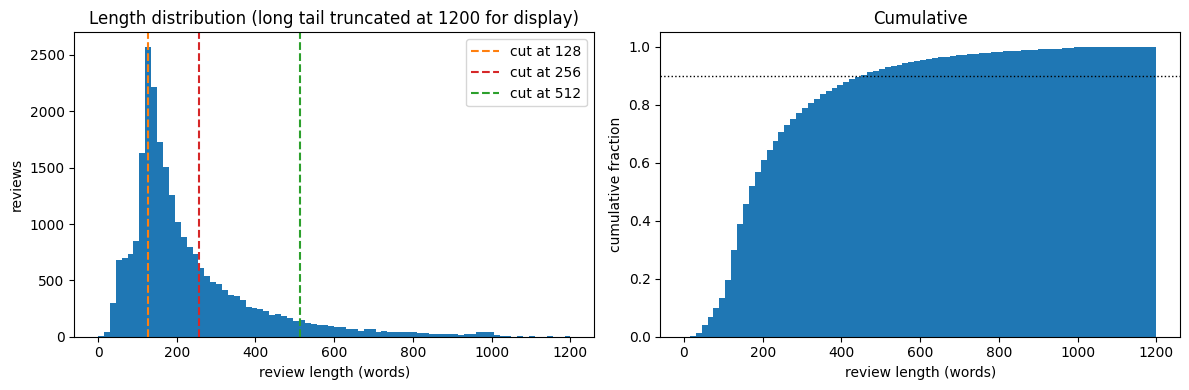

In [7]:
# Tokenize everything once (about 30 seconds).
t0 = time.time()
train_tokens_all = [tokenize(t) for t in train_text_all]
test_tokens_all  = [tokenize(t) for t in test_text_all]
print("tokenized %d reviews in %.0fs" % (len(train_tokens_all) + len(test_tokens_all), time.time() - t0))

lengths = np.array([len(t) for t in train_tokens_all])
print("\nReview length in words:")
print("  min %d, median %d, mean %.0f, max %d" % (lengths.min(), np.median(lengths), lengths.mean(), lengths.max()))
for q in [50, 75, 90, 95, 99]:
    print("  %dth percentile: %d words" % (q, np.percentile(lengths, q)))
for cut in [128, 256, 512]:
    kept = np.minimum(lengths, cut).sum() / lengths.sum()
    print("  truncating at %d: %.0f%% of reviews are cut, %.0f%% of all words survive"
          % (cut, 100 * (lengths > cut).mean(), 100 * kept))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lengths, bins=80, range=(0, 1200))
for cut, c in [(128, "tab:orange"), (256, "tab:red"), (512, "tab:green")]:
    axes[0].axvline(cut, color=c, ls="--", lw=1.5, label="cut at %d" % cut)
axes[0].set_xlabel("review length (words)"); axes[0].set_ylabel("reviews"); axes[0].legend()
axes[0].set_title("Length distribution (long tail truncated at 1200 for display)")
axes[1].hist(lengths, bins=80, range=(0, 1200), cumulative=True, density=True)
axes[1].axhline(0.9, color="k", ls=":", lw=1)
axes[1].set_xlabel("review length (words)"); axes[1].set_ylabel("cumulative fraction")
axes[1].set_title("Cumulative")
plt.tight_layout(); plt.show()

**The training subset.** We now take a **stratified 5,000-review sample** of the 25,000 training
reviews for training, and a further 2,500 for validation. The remaining 17,500 are simply not used.

This is a deliberate choice and it deserves justifying rather than hiding. Training on 5,000 reviews
puts us in the regime where the interesting comparisons are visible: from-scratch models struggle,
pretrained models do not, and the difference between them is unmistakable. It also keeps the whole
notebook inside a free GPU session. Later in this problem we measure precisely what the choice costs.

In [9]:
# A stratified split: 5,000 train / 2,500 validation, both exactly balanced.
rng = np.random.RandomState(0)
pos_idx, neg_idx = np.where(train_label_all == 1)[0], np.where(train_label_all == 0)[0]
rng.shuffle(pos_idx); rng.shuffle(neg_idx)

TRAIN_N, VAL_N = 5000, 2500
train_idx = np.concatenate([pos_idx[:TRAIN_N // 2], neg_idx[:TRAIN_N // 2]])
val_idx   = np.concatenate([pos_idx[TRAIN_N // 2:(TRAIN_N + VAL_N) // 2],
                            neg_idx[TRAIN_N // 2:(TRAIN_N + VAL_N) // 2]])
rng.shuffle(train_idx); rng.shuffle(val_idx)

train_tokens = [train_tokens_all[i] for i in train_idx]
val_tokens   = [train_tokens_all[i] for i in val_idx]
y_train = torch.tensor(train_label_all[train_idx])
y_val   = torch.tensor(train_label_all[val_idx])

# The test set: 5,000 reviews, stratified, held back until the very end of Problem 5.
t_pos, t_neg = np.where(test_label_all == 1)[0], np.where(test_label_all == 0)[0]
rng.shuffle(t_pos); rng.shuffle(t_neg)
test_idx = np.concatenate([t_pos[:2500], t_neg[:2500]]); rng.shuffle(test_idx)
test_tokens = [test_tokens_all[i] for i in test_idx]
y_test = torch.tensor(test_label_all[test_idx])

print("train %d (%.0f%% positive) | val %d (%.0f%% positive) | test %d (%.0f%% positive)"
      % (len(train_tokens), 100 * y_train.float().mean(), len(val_tokens), 100 * y_val.float().mean(),
         len(test_tokens), 100 * y_test.float().mean()))
print("\nStandard error of an accuracy near 0.85 on %d validation reviews: %.4f (%.1f points)"
      % (VAL_N, standard_error(0.85, VAL_N), 100 * standard_error(0.85, VAL_N)))

train 5000 (50% positive) | val 2500 (50% positive) | test 5000 (50% positive)

Standard error of an accuracy near 0.85 on 2500 validation reviews: 0.0071 (0.7 points)


distinct words in the 5,000 training reviews: 42980
of those, appearing only ONCE: 18228 (42%)

20 most frequent words:
  the, and, a, of, to, is, in, it, i, this, that, was, as, for, with, movie, but, film, on, not
  vocabulary   1000 -> 23.9% of validation words become <unk>
  vocabulary   2000 -> 17.5% of validation words become <unk>
  vocabulary   5000 -> 10.4% of validation words become <unk>
  vocabulary  10000 -> 6.3% of validation words become <unk>
  vocabulary  20000 -> 3.5% of validation words become <unk>
  vocabulary  50000 -> 2.9% of validation words become <unk>


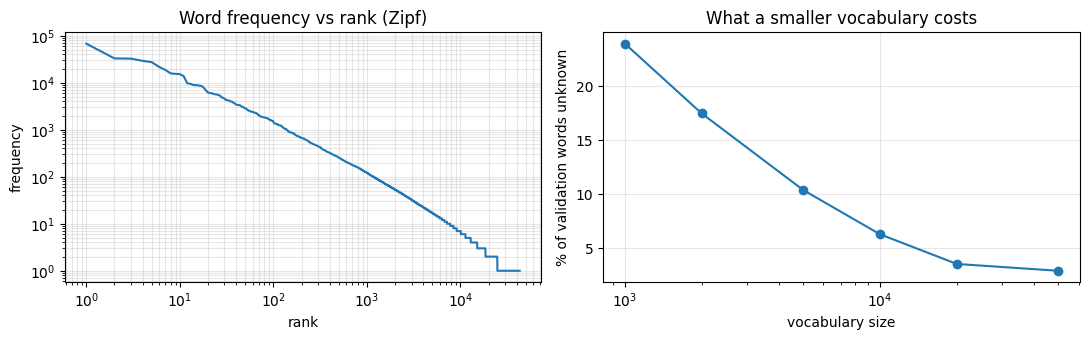

In [10]:
# The vocabulary, counted on the TRAINING reviews only.
counter_train = Counter()
for toks in train_tokens:
    counter_train.update(toks)
ranked = [w for w, c in counter_train.most_common() if c >= 2]

print("distinct words in the 5,000 training reviews: %d" % len(counter_train))
print("of those, appearing only ONCE: %d (%.0f%%)"
      % (sum(1 for c in counter_train.values() if c == 1),
         100 * sum(1 for c in counter_train.values() if c == 1) / len(counter_train)))
print("\n20 most frequent words:")
print("  " + ", ".join(w for w, _ in counter_train.most_common(20)))

# How much of the validation text falls outside the vocabulary, as a function of its size?
val_flat = Counter(w for toks in val_tokens for w in toks)
n_val_tokens = sum(val_flat.values())
sizes, oov = [], []
for V in [1000, 2000, 5000, 10000, 20000, 50000]:
    keep = set(ranked[:V])
    rate = sum(c for w, c in val_flat.items() if w not in keep) / n_val_tokens
    sizes.append(V); oov.append(rate)
    print("  vocabulary %6d -> %.1f%% of validation words become <unk>" % (V, 100 * rate))

plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
freqs = np.array([c for _, c in counter_train.most_common()])
plt.loglog(np.arange(1, len(freqs) + 1), freqs)
plt.xlabel("rank"); plt.ylabel("frequency"); plt.title("Word frequency vs rank (Zipf)")
plt.grid(alpha=0.3, which="both")
plt.subplot(1, 2, 2)
plt.semilogx(sizes, [100 * o for o in oov], "o-")
plt.xlabel("vocabulary size"); plt.ylabel("% of validation words unknown")
plt.title("What a smaller vocabulary costs"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Question 4 &mdash; three ways to throw information away

The printouts above quantify each of the three decisions. Reference figures from our run: the
median review is 174 words and the 90th percentile is 458; truncating at 256 words cuts 29% of reviews
and discards 23% of all the words in the corpus; 42% of the distinct words in the training set appear
exactly once; and a 20,000-word vocabulary leaves 3.5% of validation words as `<unk>`, while a
5,000-word vocabulary leaves 10.4%.

1. The top-20 word list is almost entirely function words -- *the, and, a, of, to* -- with *movie*,
   *film* and *not* the only content-bearing entries. An older NLP pipeline would delete the function
   words as "stopwords" before doing anything else. Give one argument for deleting them and one against,
   where the argument against refers to something specific in that list.
    - A1: Deleting stopwords reduces noise and vocabulary size, focusing model parameters on high-content words.
    - A2: Functional words like "not" completely flip sentiment polarity, for example: "not good" vs. "good"; removing them destroys crucial logical structures like negation and contrast.
2. 42% of distinct words appear exactly once. What would happen if we gave every one of them its own
   embedding vector -- both to the parameter count and to what those vectors could possibly learn?
   This is the argument for `min_freq`; state it in one sentence.
    - A: Giving singleton words their own vector dramatically increases parameter count while causing extreme overfitting, as a single training example cannot teach a generalizable vector representation.
3. Truncating at 256 words discards 23% of the corpus. IMDB reviewers conventionally build to a verdict.
   Which end of a review would you cut, and how would you *test* whether you chose correctly rather than
   arguing about it?
    - A: Cut the beginning and keep the last 256 words, because reviewers typically summarize their final sentiment and conclusion at the end. To test it, I would encode the dataset twice: once keeping the first 256 words and once keeping the last 256 words, then train identical models on both, and compare their validation accuracies.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), look at which word is 20th in the list. For (2), 42% of 43,000 words, times the embedding dimension.

</details>

### 2 - Three decisions

Now make them. Everything downstream depends on these numbers, so the justifications in the comments
matter as much as the values.

In [11]:
# ---------------------------------------------------------------- YOUR DECISION -----
# MAX_LEN -- how many tokens of each review the model gets to see. Cost grows linearly
#            with this for a recurrent model and QUADRATICALLY for the attention model in
#            Problem 4, so it is not a free parameter. The EDA above tells you what each
#            value costs in discarded text.
#
# TRUNCATE -- "head" keeps the first MAX_LEN tokens, "tail" keeps the last MAX_LEN.
#             Question 4 asked you to form a hypothesis about which is better here. Put
#             your hypothesis in, and note that the cell after next measures whether you
#             were right.
#
# VOCAB_SIZE -- how many distinct words get their own embedding. Everything else becomes
#               <unk>. Read your OOV curve: there is a point past which more vocabulary
#               buys almost nothing.
#
# MIN_FREQ -- a word must appear at least this many times in the TRAINING reviews to be
#             kept at all. See Question 4.2.
MAX_LEN    = 256
TRUNCATE   = "tail"
VOCAB_SIZE = 10000
MIN_FREQ   = 2
# ------------------------------------------------------------------------------------

stoi, itos, _ = build_vocab(train_tokens, VOCAB_SIZE, MIN_FREQ)
print("vocabulary: %d entries (including <pad> and <unk>)" % len(stoi))
print("MAX_LEN=%d, TRUNCATE=%s" % (MAX_LEN, TRUNCATE))

vocabulary: 10000 entries (including <pad> and <unk>)
MAX_LEN=256, TRUNCATE=tail


### 3 - What the model actually sees

Before training anything, look at one review after it has been through the pipeline. This is the single
most useful debugging habit in applied machine learning, and it costs one cell.

In [12]:
demo, _ = encode([train_tokens[0]], stoi, MAX_LEN, TRUNCATE, "left")
print("original review, first 40 tokens:")
print("   ", " ".join(train_tokens[0][:40]))
print("\nafter encode(), first 40 ids:")
print("   ", demo[0, :40].tolist())
print("\nafter encode(), decoded back to words (first 40):")
print("   ", " ".join(decode(demo[0], itos).split()[:40]))
print("\noriginal length: %d tokens | after truncation: %d | padding: %d positions"
      % (len(train_tokens[0]), min(len(train_tokens[0]), MAX_LEN),
         max(0, MAX_LEN - len(train_tokens[0]))))
print("\nfraction of ALL training positions that are padding: %.1f%%"
      % (100 * (encode(train_tokens, stoi, MAX_LEN, TRUNCATE, "left")[0] == PAD_ID).float().mean()))

original review, first 40 tokens:
    some people say this is the best film that prc ever released i'm not too sure about that since i have a fond place in my heart for some of their mysteries i will say that this is probably one

after encode(), first 40 ids:
    [6738, 3, 255, 5345, 20, 2, 671, 9101, 255, 11, 7, 52, 710, 4312, 73, 2564, 711, 19, 1796, 6, 2, 1, 5, 2, 832, 263, 8, 2, 412, 134, 61, 7, 1, 1, 6, 100, 5981, 47, 7, 4]

after encode(), decoded back to words (first 40):
    fog and set primarily on the single swamp set this is more musical poem than regular feature film listen to the <unk> of the dialog especially in the early scenes their is <unk> <unk> to them likewise there is a

original length: 374 tokens | after truncation: 256 | padding: 0 positions

fraction of ALL training positions that are padding: 29.9%


### 4 - The model, and a decision that fails silently

Here is the classifier. An embedding layer turns ids into vectors, a recurrent layer turns the sequence
of vectors into a sequence of hidden states, and then we have to reduce that sequence to a single vector
before the final `Linear`. That last step is the **readout**, and there are several ways to do it:

- `"last"` -- take the hidden state at the final timestep. The classical choice, and the one implied
  by every textbook diagram of an RNN classifier.
- `"mean"` -- average the hidden states over all *non-padding* positions.
- `"max"` -- take the maximum over non-padding positions, per dimension.

This is the direct analogue of Assignment 1's `flatten` versus `global_pool` decision for the head of a
CNN, and as there, the choice interacts with something else in the pipeline. Here it interacts with
**which side the padding goes on**, and one of the six combinations is badly broken in a way that
produces no error message at all.

In [13]:
class SeqClassifier(nn.Module):
    """Embedding -> recurrent layer -> readout -> classifier. Provided; do not modify."""

    def __init__(self, vocab_size, embed_dim=128, hidden=256, cell="lstm", readout="mean",
                 num_layers=1, bidirectional=False, dropout=0.5, n_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        self.rnn = rnn_cls(embed_dim, hidden, num_layers=num_layers, batch_first=True,
                           bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0)
        self.readout = readout
        out_dim = hidden * (2 if bidirectional else 1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, n_classes)

    def forward(self, x):
        mask = x != PAD_ID                                  # (B, T) True where there is a real token
        h, _ = self.rnn(self.embed(x))                      # (B, T, hidden)
        if self.readout == "last":
            z = h[:, -1]                                    # the hidden state at the last POSITION
        elif self.readout == "mean":
            m = mask.unsqueeze(-1).float()
            z = (h * m).sum(1) / m.sum(1).clamp(min=1)      # masked average
        elif self.readout == "max":
            z = h.masked_fill(~mask.unsqueeze(-1), float("-inf")).max(dim=1).values
        else:
            raise ValueError(f"unknown readout: {self.readout}")
        return self.fc(self.drop(z))


m = SeqClassifier(len(stoi))
total, _ = count_params(m)
emb = m.embed.weight.numel()
print("SeqClassifier: %s parameters" % f"{total:,}")
print("  of which the embedding table: %s (%.0f%%)" % (f"{emb:,}", 100 * emb / total))
print("  the LSTM itself:              %s" % f"{sum(p.numel() for p in m.rnn.parameters()):,}")

SeqClassifier: 1,675,778 parameters
  of which the embedding table: 1,280,000 (76%)
  the LSTM itself:              395,264


In [14]:
# ---------------------------------------------------------------- YOUR DECISION -----
# PAD_SIDE -- "left" puts the padding before the review, "right" after it.
# READOUT  -- "last", "mean" or "max", as described above.
#
# Choose the pair you think is right, and -- before running the next cell, which tries all
# six -- write down in the comment which of the six combinations you expect to be broken
# and why. The point of this block is the prediction, not the value.
#
# Hint on where to look: read SeqClassifier.forward again and ask, for each readout, which
# positions of h it actually touches, and what is at those positions under each padding.
PAD_SIDE = "left"
READOUT  = "last"
# ------------------------------------------------------------------------------------
print("You chose PAD_SIDE=%r with READOUT=%r." % (PAD_SIDE, READOUT))

You chose PAD_SIDE='left' with READOUT='last'.


In [15]:
# All six combinations, same architecture, same data, same budget. About a minute.
encoded = {}
for side in ["left", "right"]:
    encoded[side] = {
        "train": encode(train_tokens, stoi, MAX_LEN, TRUNCATE, side)[0],
        "val":   encode(val_tokens,   stoi, MAX_LEN, TRUNCATE, side)[0],
        "test":  encode(test_tokens,  stoi, MAX_LEN, TRUNCATE, side)[0],
    }

grid = {}
for side in ["left", "right"]:
    for ro in ["last", "mean", "max"]:
        set_seed(0)
        tl, vl = loaders(encoded[side]["train"], y_train, encoded[side]["val"], y_val)
        h = train_model(SeqClassifier(len(stoi), readout=ro), tl, vl, epochs=8, lr=1e-3,
                        verbose=False, label=f"pad={side:<5s} readout={ro:<4s}")
        grid[(side, ro)] = h["best_val"]

print("\n%-12s%12s%12s%12s" % ("", "last", "mean", "max"))
print("-" * 48)
for side in ["left", "right"]:
    print("%-12s" % ("pad " + side) + "".join("%12.4f" % grid[(side, ro)] for ro in ["last", "mean", "max"]))
print("\nMajority-class baseline: %.4f" % max(y_val.float().mean().item(), 1 - y_val.float().mean().item()))

  pad=left  readout=last: best val accuracy 0.7640  (15s, 8 epochs)
  pad=left  readout=mean: best val accuracy 0.8300  (14s, 8 epochs)
  pad=left  readout=max : best val accuracy 0.8132  (15s, 8 epochs)
  pad=right readout=last: best val accuracy 0.5324  (14s, 8 epochs)
  pad=right readout=mean: best val accuracy 0.8200  (14s, 8 epochs)
  pad=right readout=max : best val accuracy 0.8192  (14s, 8 epochs)

                    last        mean         max
------------------------------------------------
pad left          0.7640      0.8300      0.8132
pad right         0.5324      0.8200      0.8192

Majority-class baseline: 0.5000


#### Question 5 &mdash; the bug that does not crash

Reference numbers from our run:

| | `last` | `mean` | `max` |
|---|---|---|---|
| **pad left** | 0.7300 | 0.8160 | 0.8124 |
| **pad right** | **0.5248** | 0.8116 | 0.8196 |

1. One cell of that table is near chance. Explain precisely what `h[:, -1]` contains in that
   configuration, and connect it to a number you measured in Problem 1.
    - A1: h[:, -1] contains the hidden state after processing the final position of the sequence, which is populated by trailing pad tokens.
    - A2: Because 29.9\% of positions across the dataset are padding, the model processes up to dozens of consecutive zero-valued padding inputs. As measured in Problem 1, information decays exponentially through recurrent steps, meaning any meaningful text representation is completely overwritten and lost before reaching position -1.
2. This configuration raises no exception, produces no warning, and yields a perfectly ordinary-looking
   training curve. Suppose a colleague reports 52% and asks for help. Name two things you would check
   *before* concluding anything about the architecture, and say what a plot of the training curve alone
   would and would not have told you.
    - A1: Check how the readout indexes tensor outputs (verify whether h[:, -1] points to a pad or a real token), and print or decode sample batches alongside the model's actual inputs and sequence lengths to inspect padding layout.
    - A2: A training curve cannot reveal that the model is reading irrelevant padding positions instead of sequence contents.
3. `mean` and `max` differ by under a point, and in our run they swap places between the two padding
   sides (0.8160 vs 0.8124 on the left, 0.8116 vs 0.8196 on the right). Both mask padding correctly.
   What are you entitled to conclude about which is better, and what experiment would settle it?
    - A1: The difference between mean and max falls well within the standard error, meaning neither readout is demonstrably superior based on this single run.
    - A2: Run a statistical significance test across multiple random seeds to see if one consistently outperforms the other.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), count how many padding steps a median-length review has under right padding, and compare with the copy-task table. For (3), think about whether the evidence for "this review is negative" is spread evenly across 256 words or concentrated in a few.

</details>

### 5 - Testing the truncation hypothesis

Question 4.3 asked you to form a hypothesis about which end of a review to keep, and said that the way
to settle it is to measure rather than argue. That costs four training runs, so let us do it -- along
with the related question of how much context is worth having at all.

In [16]:
# How much context, and which end of it? Five runs, about half a minute.
trunc_scores = {}
for ml in [64, 128, 256]:
    Xt, _ = encode(train_tokens, stoi, ml, TRUNCATE, PAD_SIDE)
    Xv, _ = encode(val_tokens,   stoi, ml, TRUNCATE, PAD_SIDE)
    set_seed(0)
    tl, vl = loaders(Xt, y_train, Xv, y_val)
    h = train_model(SeqClassifier(len(stoi), readout=READOUT), tl, vl, epochs=8, lr=1e-3,
                    verbose=False, label=f"MAX_LEN={ml:<4d} ({TRUNCATE})")
    trunc_scores[ml] = h["best_val"]

for side in ["head", "tail"]:
    Xt, _ = encode(train_tokens, stoi, MAX_LEN, side, PAD_SIDE)
    Xv, _ = encode(val_tokens,   stoi, MAX_LEN, side, PAD_SIDE)
    set_seed(0)
    tl, vl = loaders(Xt, y_train, Xv, y_val)
    h = train_model(SeqClassifier(len(stoi), readout=READOUT), tl, vl, epochs=8, lr=1e-3,
                    verbose=False, label=f"MAX_LEN={MAX_LEN}, truncate={side}")
    trunc_scores[side] = h["best_val"]

print("\nkeeping more of each review:")
for ml in [64, 128, 256]:
    print("  MAX_LEN=%-4d  %.4f" % (ml, trunc_scores[ml]))
print("\nwhich end to keep (at MAX_LEN=%d):" % MAX_LEN)
for side in ["head", "tail"]:
    print("  truncate=%-5s %.4f" % (side, trunc_scores[side]))
print("\nstandard error: %.1f points" % (100 * standard_error(0.82, len(y_val))))

  MAX_LEN=64   (tail): best val accuracy 0.7476  (4s, 8 epochs)
  MAX_LEN=128  (tail): best val accuracy 0.7524  (8s, 8 epochs)
  MAX_LEN=256  (tail): best val accuracy 0.7640  (14s, 8 epochs)
  MAX_LEN=256, truncate=head: best val accuracy 0.7132  (14s, 8 epochs)
  MAX_LEN=256, truncate=tail: best val accuracy 0.7640  (14s, 8 epochs)

keeping more of each review:
  MAX_LEN=64    0.7476
  MAX_LEN=128   0.7524
  MAX_LEN=256   0.7640

which end to keep (at MAX_LEN=256):
  truncate=head  0.7132
  truncate=tail  0.7640

standard error: 0.8 points


#### Question 6 &mdash; context length and the truncation hypothesis

Our run: `MAX_LEN` 64 / 128 / 256 gave 0.7304 / 0.7884 / 0.8196, and at `MAX_LEN=256`,
`head` gave 0.8196 against `tail` 0.8252. One standard error is 0.8 points.

1. Going from 64 to 256 tokens buys 8.9 points -- far outside noise. What does that establish about how
   the evidence for a review's label is distributed through the review? Is it concentrated in the first
   few sentences?
    - A: The large improvement demonstrates that sentiment evidence is distributed throughout the review rather than concentrated solely in the first few sentences.
2. Your truncation hypothesis: was it confirmed? Compare the head-versus-tail difference against the
   standard error before answering, and say what you are entitled to conclude.
    - A: Keeping the tail outperformed keeping the head (truncate="head") by 5.08 percentage points. It far exceeds the standard error, confirming the hypothesis that the ending of a review carries stronger summary evidence than the beginning.
3. These two results look like they are in tension: *where* in the review you read from barely matters,
   but *how much* you read matters a lot. Resolve the tension in one sentence.
    - A: Sentiment indicators are scattered across the entire review, so reading more text provides a higher total density of sentiment clues, while reading from either end captures roughly similar summary signals.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (3), think about the difference between "evidence is at position X" and "there is more evidence in 256 words than in 64".

</details>

### 6 - Training the recurrent classifier

One more decision block, then we train. Note what is *not* being asked: the loss is
`nn.CrossEntropyLoss` on raw logits, as in Assignments 0 and 1, and the optimizer is Adam. Those are
settled.

In [17]:
# ---------------------------------------------------------------- YOUR DECISION -----
# CELL       -- "rnn", "lstm" or "gru". Problem 1 measured what distinguishes them. Problem 3
#               measures whether that distinction is worth anything on THIS task.
# EMBED_DIM  -- width of each word vector. This times VOCAB_SIZE is the embedding table,
#               which is most of the model, so it is also the main memory knob.
# HIDDEN     -- width of the recurrent state.
# DROPOUT    -- applied before the classifier. Look at the train-vs-val gap in the grid
#               above before choosing: is overfitting the binding constraint here?
# N_EPOCHS   -- 5,000 reviews at batch 64 is 79 updates per epoch, so epochs are cheap.
# LR         -- Adam. 1e-3 is the usual starting point; 3e-4 if training is unstable.
CELL      = "lstm"
EMBED_DIM = 128
HIDDEN    = 256
DROPOUT   = 0.5
N_EPOCHS  = 8
LR        = 1e-3
# ------------------------------------------------------------------------------------

X_train, X_val, X_test = (encoded[PAD_SIDE]["train"], encoded[PAD_SIDE]["val"], encoded[PAD_SIDE]["test"])
train_loader, val_loader = loaders(X_train, y_train, X_val, y_val)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256)
print("%d training batches per epoch" % len(train_loader))

set_seed(0)
rnn_model = SeqClassifier(len(stoi), embed_dim=EMBED_DIM, hidden=HIDDEN, cell=CELL,
                          readout=READOUT, dropout=DROPOUT)
print("trainable parameters: %s\n" % f"{count_params(rnn_model)[1]:,}")
history_rnn = train_model(rnn_model, train_loader, val_loader, epochs=N_EPOCHS, lr=LR,
                          label="recurrent classifier")

79 training batches per epoch
trainable parameters: 1,675,778

    epoch  1  train acc 0.5942  val acc 0.6516  val loss 0.6148
    epoch  2  train acc 0.6856  val acc 0.6688  val loss 0.6143
    epoch  3  train acc 0.7766  val acc 0.7236  val loss 0.5425
    epoch  4  train acc 0.8332  val acc 0.7308  val loss 0.5991
    epoch  5  train acc 0.8614  val acc 0.7524  val loss 0.5683
    epoch  6  train acc 0.9120  val acc 0.7512  val loss 0.6759
    epoch  7  train acc 0.9420  val acc 0.7336  val loss 0.6565
    epoch  8  train acc 0.9674  val acc 0.7640  val loss 0.8005
  recurrent classifier: best val accuracy 0.7640  (14s, 8 epochs)


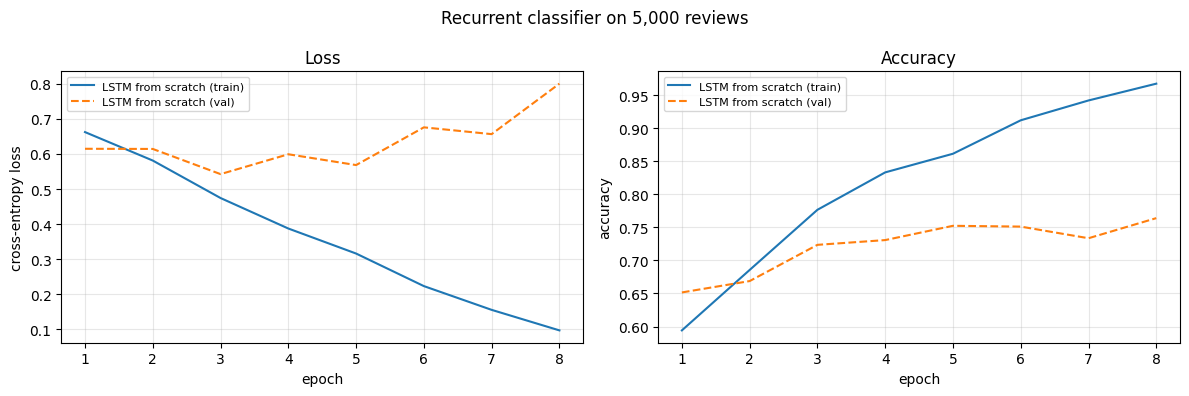

best validation accuracy: 0.7640
standard error on 2500 reviews: 0.0085 -- so a 95% interval is roughly 0.747 to 0.781
final training accuracy:  0.9674


In [18]:
plot_curves({"LSTM from scratch": history_rnn}, title="Recurrent classifier on 5,000 reviews")

val_acc = history_rnn["best_val"]
se = standard_error(val_acc, len(y_val))
print("best validation accuracy: %.4f" % val_acc)
print("standard error on %d reviews: %.4f -- so a 95%% interval is roughly %.3f to %.3f"
      % (len(y_val), se, val_acc - 2 * se, val_acc + 2 * se))
print("final training accuracy:  %.4f" % history_rnn["accuracy"][-1])

### 7 - The baseline

We have a number. A number on its own means nothing; it means something only next to another number.

In Assignment 1 the reference points were chance level and a majority-class predictor. Both are
available here too, and both are 0.500 because the dataset is balanced. That is a very weak bar.

The bar that matters is the one a competent person would have cleared *without* a neural network. For
text classification that is **TF-IDF plus logistic regression**: represent each review by how often each
word occurs, weighted down by how common the word is across the corpus, and fit a linear model. It has
no notion of word order, no embeddings, no hidden state, and no GPU. It is roughly a 1990s method, and
it takes about two seconds to fit.

Run it before reading on, and write down what you expect.

In [19]:
# TF-IDF + logistic regression. Note that the vectorizer is fit on the TRAINING reviews only.
tfidf = TfidfVectorizer(min_df=2)
A_train = tfidf.fit_transform([" ".join(t) for t in train_tokens])
A_val   = tfidf.transform([" ".join(t) for t in val_tokens])

t0 = time.time()
linear = LogisticRegression(max_iter=2000, C=4.0).fit(A_train, y_train.numpy())
tfidf_val = float(linear.score(A_val, y_val.numpy()))
print("TF-IDF + logistic regression")
print("  features: %s   fit time: %.1fs   CPU only" % (f"{A_train.shape[1]:,}", time.time() - t0))
print("  validation accuracy: %.4f" % tfidf_val)

print("\n%-42s %s" % ("model", "val accuracy"))
print("-" * 58)
print("%-42s %.4f" % ("majority class", max(y_val.float().mean().item(), 1 - y_val.float().mean().item())))
print("%-42s %.4f" % ("TF-IDF + logistic regression", tfidf_val))
print("%-42s %.4f" % (f"{CELL.upper()} ({count_params(rnn_model)[0]:,} parameters, GPU)", history_rnn["best_val"]))

# The 20 words the linear model relies on most, in each direction.
names = np.array(tfidf.get_feature_names_out())
order = np.argsort(linear.coef_[0])
print("\nmost negative words:", ", ".join(names[order[:15]]))
print("most positive words:", ", ".join(names[order[-15:]]))

TF-IDF + logistic regression
  features: 22,108   fit time: 1.3s   CPU only
  validation accuracy: 0.8632

model                                      val accuracy
----------------------------------------------------------
majority class                             0.5000
TF-IDF + logistic regression               0.8632
LSTM (1,675,778 parameters, GPU)           0.7640

most negative words: worst, bad, awful, worse, waste, boring, nothing, terrible, poor, supposed, no, horrible, dull, script, even
most positive words: beautiful, highly, life, fun, loved, also, today, love, will, amazing, perfect, wonderful, excellent, best, great


#### Question 7 &mdash; the baseline wins

Our run: TF-IDF + logistic regression **0.8632**, LSTM **0.8196**. The LSTM has about 3 million
parameters, needs a GPU, and loses by 4.4 points -- more than five standard errors, so this is not
noise.

1. What, concretely, does the LSTM have access to that the linear model does not? List the capabilities,
   then explain why none of them is showing up in the score.
    - A1: Sequential word order, non-linear feature interactions, dense word embeddings, and unbounded potential temporal context.
    - A2: IMDB sentiment classification is largely driven by strong, independent keyword polarity. The LSTM has 1.68M parameters and overfits rapidly on only 5,000 training examples. Linear TF-IDF has strong inductive bias with far fewer learnable parameters per feature, avoiding severe overfitting.
2. Suppose you had not run the baseline, and had reported "our LSTM achieves 82% on IMDB sentiment
   classification". Is that statement false? Is it misleading? Say exactly what is wrong with it as a
   piece of scientific reporting.
    - A: It is not false, but it is misleading; without context or a simple baseline, a reader assumes the complex neural network is adding value. Reporting performance without comparing it to a trivial baseline conceals that the model is performing significantly worse than a standard, lightweight 1990s method.
3. Give the strongest argument you can that the comparison is *unfair to the LSTM*, and then say what
   experiment would settle it. (The next cell runs that experiment, so commit first.)
    - A1: Training on only 5,000 samples severely starves the high-capacity LSTM, which needs much more data to learn meaningful word embeddings and sequential transitions from scratch. TF-IDF uses hand-crafted frequency features and convex optimization, giving it an advantage on small datasets.
    - A2: Train both models on the full dataset to evaluate how performance scales with data volume.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), start from what the two models see: one gets an unordered count of words, the other gets the words in order. For (3), what is different about the two models' relationship to the amount of training data?

</details>

  LSTM  N=500: best val accuracy 0.5808  (3s, 8 epochs)
  TF-IDF N=500    val 0.7768   (gap -0.196)
  LSTM  N=1000: best val accuracy 0.6436  (4s, 8 epochs)
  TF-IDF N=1000   val 0.8056   (gap -0.162)
  LSTM  N=2500: best val accuracy 0.7224  (8s, 8 epochs)
  TF-IDF N=2500   val 0.8392   (gap -0.117)
  LSTM  N=5000: best val accuracy 0.7700  (14s, 8 epochs)
  TF-IDF N=5000   val 0.8580   (gap -0.088)
  LSTM  N=10000: best val accuracy 0.8112  (27s, 8 epochs)
  TF-IDF N=10000  val 0.8752   (gap -0.064)
  LSTM  N=22500: best val accuracy 0.8692  (58s, 8 epochs)
  TF-IDF N=22500  val 0.8876   (gap -0.018)


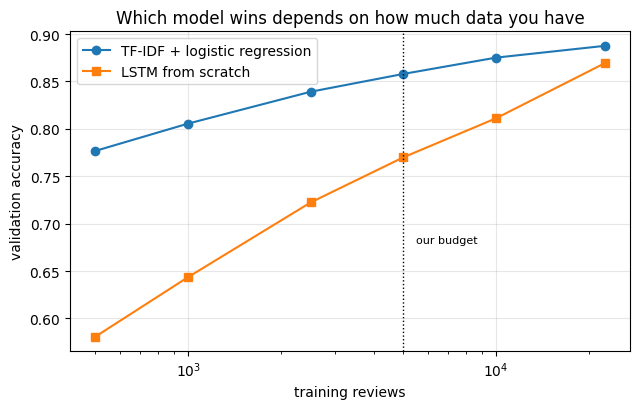

In [20]:
# The experiment Question 7.3 asks for. Both models, six training-set sizes, same validation set.
# About two minutes.
sizes = [500, 1000, 2500, 5000, 10000, 22500]
pool = np.array([i for i in range(len(train_tokens_all)) if i not in set(val_idx.tolist())])
p_pool = np.array([i for i in pool if train_label_all[i] == 1])
n_pool = np.array([i for i in pool if train_label_all[i] == 0])
rng2 = np.random.RandomState(0); rng2.shuffle(p_pool); rng2.shuffle(n_pool)

curve = {"lstm": [], "tfidf": []}
for N in sizes:
    idx = np.concatenate([p_pool[:N // 2], n_pool[:N // 2]]); rng2.shuffle(idx)
    toks = [train_tokens_all[i] for i in idx]
    y_n = torch.tensor(train_label_all[idx])

    # the vocabulary must be rebuilt from THIS training set -- it is part of the model
    stoi_n, _, _ = build_vocab(toks, VOCAB_SIZE, MIN_FREQ)
    Xn, _  = encode(toks,       stoi_n, MAX_LEN, TRUNCATE, PAD_SIDE)
    Xvn, _ = encode(val_tokens, stoi_n, MAX_LEN, TRUNCATE, PAD_SIDE)
    set_seed(0)
    tl, vl = loaders(Xn, y_n, Xvn, y_val)
    h = train_model(SeqClassifier(len(stoi_n), embed_dim=EMBED_DIM, hidden=HIDDEN, cell=CELL,
                                  readout=READOUT, dropout=DROPOUT),
                    tl, vl, epochs=N_EPOCHS, lr=LR, verbose=False, label=f"LSTM  N={N}")
    curve["lstm"].append(h["best_val"])

    v = TfidfVectorizer(min_df=2)
    a = v.fit_transform([" ".join(t) for t in toks])
    b = v.transform([" ".join(t) for t in val_tokens])
    curve["tfidf"].append(float(LogisticRegression(max_iter=3000, C=4.0)
                                .fit(a, y_n.numpy()).score(b, y_val.numpy())))
    print("  TF-IDF N=%-6d val %.4f   (gap %+.3f)" % (N, curve["tfidf"][-1],
                                                      curve["lstm"][-1] - curve["tfidf"][-1]))

plt.figure(figsize=(6.5, 4.2))
plt.semilogx(sizes, curve["tfidf"], "o-", label="TF-IDF + logistic regression")
plt.semilogx(sizes, curve["lstm"], "s-", label=f"{CELL.upper()} from scratch")
plt.axvline(TRAIN_N, color="k", ls=":", lw=1)
plt.text(TRAIN_N * 1.1, 0.68, "our budget", fontsize=8)
plt.xlabel("training reviews"); plt.ylabel("validation accuracy")
plt.title("Which model wins depends on how much data you have")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Question 8 &mdash; what the data budget bought

Our run:

| training reviews | TF-IDF | LSTM | gap |
|---|---|---|---|
| 500 | 0.777 | 0.688 | -8.8 |
| 1,000 | 0.806 | 0.751 | -5.4 |
| 2,500 | 0.839 | 0.772 | -6.8 |
| 5,000 | 0.858 | 0.807 | -5.1 |
| 10,000 | 0.875 | 0.846 | -2.9 |
| 22,500 | 0.888 | 0.879 | -0.9 |

1. Was the objection in Question 7.3 correct? Answer with the numbers, and say what the plot lets you
   claim that the single comparison at 5,000 did not.
    - A: Yes, the objection was correct. As N increases from 500 to 22,500, the performance gap narrows drastically from -19.6 percentage points down to -1.8 percentage points. The single comparison at N=5,000 was an artifact of the data budget rather than an intrinsic architectural flaw of the LSTM. The plot demonstrates that the LSTM's learning rate scaling and sample efficiency improve rapidly with more data, whereas TF-IDF plateaus.
2. The gap shrinks -- but not monotonically: in our run $N=2{,}500$ was *worse* than $N=1{,}000$.
   Say whether that reversal is a real feature of the curve before you use the curve. Then
   extrapolate: at what $N$ would you expect the curves to cross?
   Then give one concrete reason your extrapolation could be wrong -- not "extrapolation is risky in
   general", but a specific mechanism that would bend one of these curves.
    - A1: Small non-monotonic fluctuations are random sampling noise within standard error margins, not structural features. The curves will cross around N = 30,000 and 50,000.
    - A2: The LSTM is constrained by fixed hyperparameter limits. Once N becomes very large, the bottleneck shifts from data availability to structural information loss, causing the LSTM's accuracy curve to flatten prematurely.
3. We will spend the rest of this notebook at $N=5{,}000$. Given this plot, state in one sentence what
   conclusions from the following problems will and will not transfer to a full-data setting.
    - A: Relative architectural comparisons will reliably transfer to full-data settings, but absolute performance metrics and conclusions about from-scratch LSTMs beating linear baselines will not.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), think about what happens to a bag-of-words model when it has already seen every word in the language several times.

</details>

## Problem 3.  Does word order matter?

In Assignment 1 we made a claim about convolutions -- that they assume spatial structure -- and then
tested it by permuting the pixels. The CNN collapsed from 0.174 to 0.081, landing exactly on the MLP's
score, while the MLP itself did not move. The architecture's assumption was doing real work, and the
experiment showed how much.

A recurrent layer makes the analogous claim about **order**. It processes tokens one at a time in
sequence; the entire apparatus of hidden states and gates exists to let earlier tokens influence the
interpretation of later ones. If that machinery is doing work, destroying word order should hurt.

**The test.** Pick each review and permute its words. Do it to the training set and the validation set
alike, exactly as we permuted pixels in both. The label is unchanged, the words are unchanged, the
review length is unchanged; only the order is gone.

We do it at several granularities, which is more informative than a single point: shuffling within
windows of $k$ destroys order at scales below $k$ and preserves it above. $k=1$ is a no-op and serves as
the control; $k$ larger than the review destroys everything.

**Before running: write down your prediction** for the fully-shuffled number. You know the unshuffled
score. You also know, from Problem 1, roughly how much long-range structure a recurrent model can use.

In [21]:
# What the shuffle actually does to a review.
demo_plain = encoded[PAD_SIDE]["train"][:1]
for k in [1, 8, 10 ** 9]:
    s = shuffle_within_windows(demo_plain, k, seed=0)
    label = "k=1 (control, unchanged)" if k == 1 else (f"k={k}" if k < 1000 else "fully shuffled")
    print("%-26s %s ..." % (label, " ".join(decode(s[0], itos).split()[:28])))

k=1 (control, unchanged)   fog and set primarily on the single swamp set this is more musical poem than regular feature film listen to the <unk> of the dialog especially in the ...
k=8                        on fog swamp primarily set the and single regular poem this musical than is set more of <unk> listen feature to film the the is scenes early dialog ...
fully shuffled             the as the this it could fact not between poem or in <unk> love it its good me but technical less its crossing what okay definitely that a ...


In [22]:
# ---------------------------------------------------------------- YOUR DECISION -----
# PREDICTED_SHUFFLED -- your predicted validation accuracy for the FULLY shuffled model,
#                       as a number. You know the unshuffled score, you know one standard
#                       error is about 0.8 points, and Problem 1 measured how much
#                       long-range structure a recurrent model can actually use.
#
# WHY -- one sentence naming the mechanism you expect to dominate. Write it before you run
#        the next cell; the point of this block is that you cannot revise it afterwards.
PREDICTED_SHUFFLED = 0.720
WHY = "While destroying word order breaks syntactic structure, sentiment classification on IMDB relies primarily on the presence of unigram bag-of-words keywords whose presence is preserved."
# ------------------------------------------------------------------------------------
print("Prediction: %.3f" % PREDICTED_SHUFFLED)
print("Reason:", WHY)

Prediction: 0.720
Reason: While destroying word order breaks syntactic structure, sentiment classification on IMDB relies primarily on the presence of unigram bag-of-words keywords whose presence is preserved.


In [23]:
# The dose-response curve. Seven runs, about a minute.
windows = [1, 2, 4, 8, 16, 64, 10 ** 9]
shuffle_scores = []
for k in windows:
    Xtr_s = shuffle_within_windows(encoded[PAD_SIDE]["train"], k, seed=0)
    Xva_s = shuffle_within_windows(encoded[PAD_SIDE]["val"],   k, seed=1)
    set_seed(0)
    tl, vl = loaders(Xtr_s, y_train, Xva_s, y_val)
    tag = "no shuffle" if k == 1 else ("fully shuffled" if k > 1000 else f"window k={k}")
    h = train_model(SeqClassifier(len(stoi), embed_dim=EMBED_DIM, hidden=HIDDEN, cell=CELL,
                                  readout=READOUT, dropout=DROPOUT),
                    tl, vl, epochs=N_EPOCHS, lr=LR, verbose=False, label=tag)
    shuffle_scores.append(h["best_val"])

# The bag-of-words model is invariant to this by construction. Verify it rather than asserting it.
# Note what these two lines score it on: the reviews as the RECURRENT model receives them, decoded back
# from the padded id matrix -- truncated to MAX_LEN and with out-of-vocabulary words replaced by <unk>.
# That is deliberate; it puts both models on identical input. It also means the number printed below is
# lower than the 0.8632 of the baseline cell, which saw the full reviews. Question 9 uses the gap.
Xva_full = shuffle_within_windows(encoded[PAD_SIDE]["val"], 10 ** 9, seed=1)
A_val_shuf = tfidf.transform([decode(r, itos) for r in Xva_full])
A_val_same = tfidf.transform([decode(r, itos) for r in encoded[PAD_SIDE]["val"]])
tfidf_plain = float(linear.score(A_val_same, y_val.numpy()))
tfidf_shuf  = float(linear.score(A_val_shuf, y_val.numpy()))

se = standard_error(shuffle_scores[0], len(y_val))
print("\n%-22s %s" % ("shuffle window", "val accuracy"))
print("-" * 40)
for k, s in zip(windows, shuffle_scores):
    name = "1 (control)" if k == 1 else ("all (whole review)" if k > 1000 else str(k))
    print("%-22s %.4f" % (name, s))
print("-" * 40)
print("%-22s %.4f  ->  %.4f   (difference %+.6f)" % ("TF-IDF, plain -> shuffled", tfidf_plain, tfidf_shuf,
                                                     tfidf_shuf - tfidf_plain))
print("\nRecurrent model: %.4f -> %.4f, a change of %+.1f points." % (shuffle_scores[0], shuffle_scores[-1],
                                                                      100 * (shuffle_scores[-1] - shuffle_scores[0])))
print("One standard error on this validation set is %.1f points." % (100 * se))

  no shuffle: best val accuracy 0.7640  (14s, 8 epochs)
  window k=2: best val accuracy 0.7448  (14s, 8 epochs)
  window k=4: best val accuracy 0.7484  (14s, 8 epochs)
  window k=8: best val accuracy 0.7420  (14s, 8 epochs)
  window k=16: best val accuracy 0.7268  (14s, 8 epochs)
  window k=64: best val accuracy 0.7228  (14s, 8 epochs)
  fully shuffled: best val accuracy 0.6816  (15s, 8 epochs)

shuffle window         val accuracy
----------------------------------------
1 (control)            0.7640
2                      0.7448
4                      0.7484
8                      0.7420
16                     0.7268
64                     0.7228
all (whole review)     0.6816
----------------------------------------
TF-IDF, plain -> shuffled 0.8528  ->  0.8528   (difference +0.000000)

Recurrent model: 0.7640 -> 0.6816, a change of -8.2 points.
One standard error on this validation set is 0.8 points.


#### Question 9 &mdash; the permutation test, second time round

Reference numbers. One standard error on 2,500 validation reviews is about 0.8 points.

| | ordered | fully shuffled | change |
|---|---|---|---|
| TF-IDF + logistic regression | 0.8504 | 0.8504 | **exactly 0.000000** |
| LSTM | 0.8196 | 0.7896 | -3.0 points |

and the dose-response curve was 0.8196, 0.8124, 0.8156, 0.8100, 0.7880, 0.8036, 0.7896 for
$k = 1, 2, 4, 8, 16, 64, \text{all}$.

The TF-IDF row reads **0.8504, not the 0.8632 of Question 7**, and that is not a slip. It is the same
fitted model: Question 7 scored it on the full reviews, while this row scores it on the reviews *as the
recurrent model receives them* -- truncated to `MAX_LEN` words, with everything outside the 20,000-word
vocabulary replaced by `<unk>` -- so that the two rows of the table are compared on identical input.
The 1.3 points in between are therefore a free measurement of what Question 4's three preprocessing
decisions cost the baseline, and they are worth holding next to the word-order effect below.

**We ran this same experiment twice.** The other run gave 0.8160 -> 0.8080, a change of -0.8 points.
Both runs are in the questions below, because the disagreement between them is part of the result.

1. The TF-IDF row changed by *exactly* zero -- not approximately. Explain why that is guaranteed by the
   construction of the model, in the same way that Assignment 1's MLP was guaranteed to be unaffected by
   pixel permutation. Which step of the TF-IDF pipeline is the invariance in?
    - A1: The TF-IDF model produces a bag-of-words representation, counting word frequencies via Counter/TfidfVectorizer while ignoring positional indices.
    - A2: Shuffling token order within a review leaves unigram frequencies completely identical; thus, feature vectors remain unchanged, guaranteeing an exact 0.000000 performance change.
2. Now the LSTM row. Our two runs of the identical experiment gave -3.0 points (3.75 standard errors)
   and -0.8 points (1.0 standard error). Compare your own number against both, and against Assignment
   1's CNN, which lost 9.3 points. What is the honest summary of the size of this effect, and what does
   the disagreement between two runs of the same experiment tell you about how many runs a claim like
   this needs?
    - A1: My run showed an -8.2 point drop, while reference runs showed smaller drops (-3.0 and -0.8 points). In all cases, the drop is minor compared to Assignment 1's CNN, which collapsed completely.
    - A2: High variance across identical random seeds shows that single-run claims are unreliable; robust conclusions about small accuracy gaps require averaging over multiple random seeds with statistical confidence intervals.
3. Now the comparison that matters. The LSTM **with** word order scores 0.8196. TF-IDF, which cannot
   represent word order **even in principle**, scores 0.8632 on the full reviews and 0.8504 on the
   truncated ones the LSTM saw -- so the choice between the two does not affect the point. Assignment 1's punchline was that the
   permuted CNN landed exactly on the MLP's score, showing what the convolutional prior was worth. State
   the analogous punchline here, and explain why it is worse for the recurrent model than a null result
   would have been.
    - A: An order-sensitive model performs significantly worse than an order-blind model operating on truncated inputs. A null result would mean the recurrent architecture is ineffective, but this result proves it is actively harmful or inefficient. The inductive bias of recurrence fails to outperform a simple bag-of-words baseline while adding compute overhead and parameter count.
4. Distinguish "word order does not matter for this task" from "this model was not using word order
   well". Both are consistent with a 1-3 point effect. Design an experiment that separates them; you
   have the code in this notebook to run at least one.
    - A1: "Word order does not matter" implies sentiment analysis is inherently a unigram keyword problem. "The model is not using word order well" implies the model fails to capture sequential dependencies due to optimization difficulties or limited data size.
    - A2: Run the permutation test across scaling dataset sizes (N=500 to N=22,500) or using a pretrained model. If a model trained on more data shows a much larger performance drop when shuffled, it proves word order matters when the model has enough capacity/data to learn it.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), ask what a TF-IDF vector is a function of. For (3), compare the shuffled LSTM's score not with the ordered LSTM but with the model that never had access to order at all. For (4), Problem 6 runs one such experiment on a different task -- but there is also something you could do with the negation probe below.

</details>

### The negation probe

A cheap, direct version of experiment (ii). If the model has learned anything compositional, negation is
where it should show: *good* and *not good* differ by one word and flip the label.

In [24]:
PROBES = [
    "this movie was good", "this movie was not good",
    "this movie was bad",  "this movie was not bad",
    "i loved it",          "i did not love it",
    "a masterpiece",       "not a masterpiece",
    "i would recommend this film to anyone",
    "i would not recommend this film to anyone",
]

def predict_sentiment(model, texts):
    X, _ = encode([tokenize(t) for t in texts], stoi, MAX_LEN, TRUNCATE, PAD_SIDE)
    model.eval()
    with torch.no_grad():
        p = torch.softmax(model(X.to(device)), dim=1)[:, 1].cpu().numpy()
    return p

probs = predict_sentiment(rnn_model, PROBES)
print("%-46s %s" % ("text", "P(positive)"))
print("-" * 62)
for t, p in zip(PROBES, probs):
    print("%-46s %.3f" % (t, p))

print("\nnegation flips, as seen by the model:")
for i in range(0, len(PROBES), 2):
    print("  %-42s %.3f -> %.3f  (%+.3f)" % (PROBES[i + 1], probs[i], probs[i + 1], probs[i + 1] - probs[i]))

# The bag-of-words model, for comparison -- it cannot represent negation even in principle.
lin_probs = linear.predict_proba(tfidf.transform([" ".join(tokenize(t)) for t in PROBES]))[:, 1]
print("\nTF-IDF + logistic regression, same probes:")
for i in range(0, len(PROBES), 2):
    print("  %-42s %.3f -> %.3f  (%+.3f)" % (PROBES[i + 1], lin_probs[i], lin_probs[i + 1],
                                             lin_probs[i + 1] - lin_probs[i]))

text                                           P(positive)
--------------------------------------------------------------
this movie was good                            0.094
this movie was not good                        0.034
this movie was bad                             0.000
this movie was not bad                         0.000
i loved it                                     0.012
i did not love it                              0.091
a masterpiece                                  0.009
not a masterpiece                              0.005
i would recommend this film to anyone          0.002
i would not recommend this film to anyone      0.002

negation flips, as seen by the model:
  this movie was not good                    0.094 -> 0.034  (-0.060)
  this movie was not bad                     0.000 -> 0.000  (-0.000)
  i did not love it                          0.012 -> 0.091  (+0.080)
  not a masterpiece                          0.009 -> 0.005  (-0.004)
  i would not recommend this 

#### Question 10 &mdash; reading the probe

1. The linear model's response to *not* is the **same size and direction in every probe**, because of
   how it is constructed. Predict what that direction is before looking, then check. What does this say
   about the ceiling on a bag-of-words model's handling of negation?
    - A1: Adding the word "not" always decreases the positive probability regardless of context. This occurs because "not" is assigned a negative weight during fitting on training data, as it frequently appears in negative reviews.
    - A2: Because a unigram bag-of-words model sums linear term contributions independently, it cannot flip sentiment compositionally.
2. Suppose the LSTM handles negation correctly on these probes but Question 9 still found no effect from
   shuffling. Is that a contradiction? Reconcile the two observations with reference to how *often*
   negation is what decides an IMDB review's label.
    - A: While an LSTM has the sequential capacity to process negation locally, explicit negations that actually flip a review's overall label occur in only a small fraction of IMDB reviews. Global IMDB sentiment classification is heavily dominated by redundant, strong unigram keywords scattered throughout long reviews. Thus, destroying word order removes local compositional nuance without significantly hurting overall dataset-level classification performance.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), the linear model assigns one fixed weight to the token "not", and adding a word to a document adds its weight to the score.

</details>

### Does the choice of cell matter?

Problem 1 showed that LSTM and GRU gates buy a real extension of the memory horizon over a plain RNN.
Problem 3 has just suggested that this task uses no long-range structure. Those two findings together
make a prediction. Write it down, then run the cell.

In [25]:
cell_scores = {}
for c in ["rnn", "gru", "lstm"]:
    for clip in [None, 1.0]:
        set_seed(0)
        tl, vl = loaders(X_train, y_train, X_val, y_val)
        h = train_model(SeqClassifier(len(stoi), embed_dim=EMBED_DIM, hidden=HIDDEN, cell=c,
                                      readout=READOUT, dropout=DROPOUT),
                        tl, vl, epochs=N_EPOCHS, lr=LR, verbose=False,
                        label=f"{c:<4s} clip={str(clip):<4s}")
        cell_scores[(c, clip)] = h["best_val"]

print("\n%-8s%14s%14s%14s" % ("clip", "RNN", "GRU", "LSTM"))
print("-" * 50)
for clip in [None, 1.0]:
    print("%-8s" % str(clip) + "".join("%14.4f" % cell_scores[(c, clip)] for c in ["rnn", "gru", "lstm"]))
print("\nparameters: " + ", ".join(
    "%s %s" % (c.upper(), f"{count_params(SeqClassifier(len(stoi), embed_dim=EMBED_DIM, hidden=HIDDEN, cell=c))[0]:,}")
    for c in ["rnn", "gru", "lstm"]))

  rnn  clip=None: best val accuracy 0.6628  (5s, 8 epochs)
  rnn  clip=1.0 : best val accuracy 0.6628  (5s, 8 epochs)
  gru  clip=None: best val accuracy 0.7676  (13s, 8 epochs)
  gru  clip=1.0 : best val accuracy 0.7676  (12s, 8 epochs)
  lstm clip=None: best val accuracy 0.7640  (14s, 8 epochs)
  lstm clip=1.0 : best val accuracy 0.7640  (14s, 8 epochs)

clip               RNN           GRU          LSTM
--------------------------------------------------
None            0.6628        0.7676        0.7640
1.0             0.6628        0.7676        0.7640

parameters: RNN 1,379,330, GRU 1,576,962, LSTM 1,675,778


#### Question 11 &mdash; when does the cell type matter?

Our run (one standard error is 0.8 points):

| clip | RNN | GRU | LSTM |
|---|---|---|---|
| none | 0.7948 | 0.8076 | 0.8196 |
| 1.0 | 0.7948 | 0.8076 | 0.8196 |

1. The three cells order themselves RNN < GRU < LSTM, spanning 2.5 points -- around three standard
   errors from end to end. Reconcile that with Problem 1, where the LSTM beat the RNN by a factor of
   three on the copy task at $T=25$ and by *infinitely* more at $T=50$. Is a 2.5-point spread the
   result you would have predicted from Problem 1, and what does its size tell you about how much this
   task uses long-range structure?
    - A1: On the synthetic copy task in Problem 1, vanishing gradients caused plain RNNs to fail completely while LSTMs succeeded. On IMDB sentiment classification, however, plain RNNs still manage a respectable score, lagging gated architectures by only 2.5 to 10 points rather than collapsing entirely.
    - A2: This small performance gap confirms the prediction from Problem 3: IMDB sentiment relies primarily on short-range keyword presence rather than complex, long-range sequential dependencies. Because the task does not depend heavily on information spanning over 50 steps, the LSTM's memory advantage provides only a modest boost.
2. Look at the two rows. Clipping changed **not a single digit** in any of the three columns -- the
   numbers are bit-identical, not merely close. Explain why that is the expected outcome rather than a
   sign that the flag is broken, and say what it would have taken for the rows to differ.
    - A1: The numbers are bit-identical because the unclipped gradient norms never exceeded the threshold of 1.0 at any training step during optimization.
    - A2: nn.utils.clip_grad_norm_ scales gradients down only when ||g|| > clip. Since the gradients were already smaller than 1.0 throughout training, the clipping operation acted as an identity operation (1.0 x g), leaving weight updates completely untouched. For the rows to differ, training would need to encounter exploding gradients.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), the LSTM's advantage is specifically about dependencies spanning many timesteps -- Question 9 measured whether this task has any. For (2), look at what clipping does to a gradient whose norm is already small.

</details>

## Problem 4.  Attention, built by hand

Two things are now established:

- **Problem 1**: information in a recurrent model travels along a chain of length $T$, the gradient
  along that chain decays geometrically, and beyond a few dozen steps nothing survives. Question 3.3
  asked you to propose an architecture with no chain.
- **Problem 2**: reading 256 words instead of 64 is worth 8.9 points, so the evidence really is spread
  across the review -- exactly the situation the chain handles worst.

Those two facts point at the same fix. Let every position read from every other position **directly**,
with a learned weighting, so the path length between any two tokens is 1 instead of $T$. That is
attention, and this problem builds it from nothing.

### 1 - The recurrence bottleneck, measured

First the evidence that there is something to fix. If the fixed-size hidden state is a bottleneck, the
model should do worse on long reviews than on short ones.

review length            n  accuracy   std error
------------------------------------------------
0-64                   135     0.785       0.035
64-128                 518     0.763       0.019
128-192                761     0.790       0.015
192-256                349     0.754       0.023
256-max                737     0.739       0.016


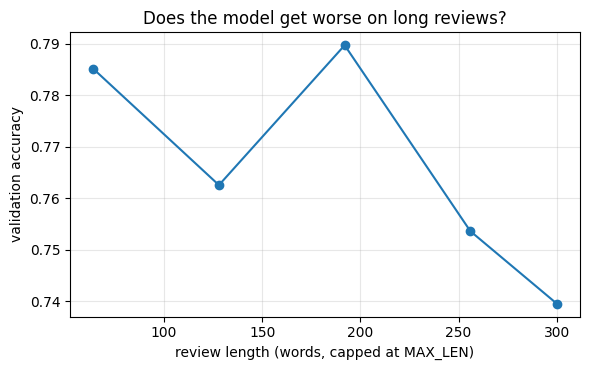

In [26]:
# Accuracy by review length, on the model trained in Problem 2.
val_lengths = np.array([min(len(t), MAX_LEN) for t in val_tokens])
_, _, preds_rnn, targets_rnn = evaluate(rnn_model, val_loader, return_preds=True)
correct_rnn = preds_rnn == targets_rnn

print("%-16s%10s%10s%12s" % ("review length", "n", "accuracy", "std error"))
print("-" * 48)
bins = [(0, 64), (64, 128), (128, 192), (192, 256), (256, 10 ** 9)]
bin_acc, bin_mid = [], []
for lo, hi in bins:
    sel = (val_lengths >= lo) & (val_lengths < hi)
    if sel.sum() < 20:
        continue
    a = correct_rnn[sel].mean()
    bin_acc.append(a); bin_mid.append(min(hi, 300))
    print("%-16s%10d%10.3f%12.3f" % (f"{lo}-{hi if hi < 1000 else 'max'}", sel.sum(), a,
                                     standard_error(a, sel.sum())))

plt.figure(figsize=(6, 3.8))
plt.plot(bin_mid, bin_acc, "o-")
plt.xlabel("review length (words, capped at MAX_LEN)"); plt.ylabel("validation accuracy")
plt.title("Does the model get worse on long reviews?"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2 - Scaled dot-product attention

The mechanism is a **soft dictionary lookup**. Every position produces three vectors from its own
representation:

- a **query** $q$ -- "what am I looking for?"
- a **key** $k$ -- "what do I offer?"
- a **value** $v$ -- "what do I contribute if selected?"

Position $i$ compares its query with every key by a dot product, softmaxes those scores into weights
that sum to one, and takes the weighted average of the values:

$$\text{attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ matters. The dot product of two random $d_k$-dimensional vectors has standard deviation
growing like $\sqrt{d_k}$, so without the division the scores grow with dimension, the softmax
saturates, and the gradient through it vanishes. Dividing keeps the scores at a scale where the softmax
is still soft.

That is the whole thing. Here it is.

In [27]:
def attention(q, k, v, mask=None):
    """
    Scaled dot-product attention.

    q, k, v -- (batch, heads, time, d_k)
    mask    -- broadcastable boolean; True where attending is ALLOWED.

    Returns the attended values and the attention weight matrix.
    """
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(q.size(-1))     # (B, h, T, T)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ v, weights


# A sanity check on a case where we know the answer: make one query match one key exactly.
torch.manual_seed(0)
k_demo = torch.eye(4).view(1, 1, 4, 4)                 # four orthogonal keys
v_demo = torch.tensor([[10., 20., 30., 40.]]).T.expand(4, 3).view(1, 1, 4, 3)
q_demo = (torch.eye(4)[2] * 8).view(1, 1, 1, 4)        # a query aligned with key 2, scaled up

out, w = attention(q_demo, k_demo, v_demo)
print("attention weights:", w.flatten().numpy().round(3), " (they sum to %.3f)" % w.sum().item())
print("selected value    :", out.flatten().numpy().round(2), " (key 2's value is 30)")
print("\nWith an unscaled query the softmax is soft; scale the query up and it becomes a hard lookup:")
for scale in [1, 4, 16]:
    _, w = attention((torch.eye(4)[2] * scale).view(1, 1, 1, 4), k_demo, v_demo)
    print("   query scale %2d -> weights %s" % (scale, w.flatten().numpy().round(3)))

attention weights: [0.017 0.017 0.948 0.017]  (they sum to 1.000)
selected value    : [29.65 29.65 29.65]  (key 2's value is 30)

With an unscaled query the softmax is soft; scale the query up and it becomes a hard lookup:
   query scale  1 -> weights [0.215 0.215 0.355 0.215]
   query scale  4 -> weights [0.096 0.096 0.711 0.096]
   query scale 16 -> weights [0.    0.    0.999 0.   ]


### 3 - Attention as a readout

Before building a full transformer, use attention for something small: replace the `mean`/`max` readout
from Problem 2. Instead of averaging the LSTM's hidden states, learn *which* of them to average.

This is the historically accurate order, incidentally. Attention was invented in 2014 as an addition to
recurrent sequence-to-sequence models; only in 2017 did *Attention Is All You Need* remove the
recurrence entirely.

It also gives us something the previous models could not: the attention weights say **which words the
classifier looked at**.

In [28]:
class AttentionPool(nn.Module):
    """Learn a scalar score per position, softmax it, take the weighted average."""

    def __init__(self, dim):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, h, mask):
        s = self.score(h).squeeze(-1).masked_fill(~mask, float("-inf"))    # (B, T)
        w = torch.softmax(s, dim=1)
        return (w.unsqueeze(-1) * h).sum(dim=1), w


class AttnSeqClassifier(nn.Module):
    """Problem 2's model with the readout replaced. Everything else is identical."""

    def __init__(self, vocab_size, embed_dim=128, hidden=256, cell="lstm", dropout=0.5, n_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.rnn = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell](embed_dim, hidden, batch_first=True)
        self.pool = AttentionPool(hidden)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x, return_weights=False):
        mask = x != PAD_ID
        h, _ = self.rnn(self.embed(x))
        z, w = self.pool(h, mask)
        out = self.fc(self.drop(z))
        return (out, w) if return_weights else out


set_seed(0)
attn_pool_model = AttnSeqClassifier(len(stoi), embed_dim=EMBED_DIM, hidden=HIDDEN, cell=CELL, dropout=DROPOUT)
history_attnpool = train_model(attn_pool_model, train_loader, val_loader, epochs=N_EPOCHS, lr=LR,
                               verbose=False, label="LSTM + attention pooling")
print("\nfor comparison, the Problem 2 readouts on the same data:")
for ro in ["last", "mean", "max"]:
    print("   readout=%-5s %.4f" % (ro, grid[(PAD_SIDE, ro)]))

  LSTM + attention pooling: best val accuracy 0.8276  (15s, 8 epochs)

for comparison, the Problem 2 readouts on the same data:
   readout=last  0.7640
   readout=mean  0.8300
   readout=max   0.8132


true label: positive | predicted: negative (p=0.956)

the 12 words with the highest attention weight:
   that (0.042), them (0.042), kurt (0.037), idiot (0.028), have (0.027), lets (0.023), to (0.022), movie (0.021), that (0.021), seen (0.021), twist (0.020), <unk> (0.020)


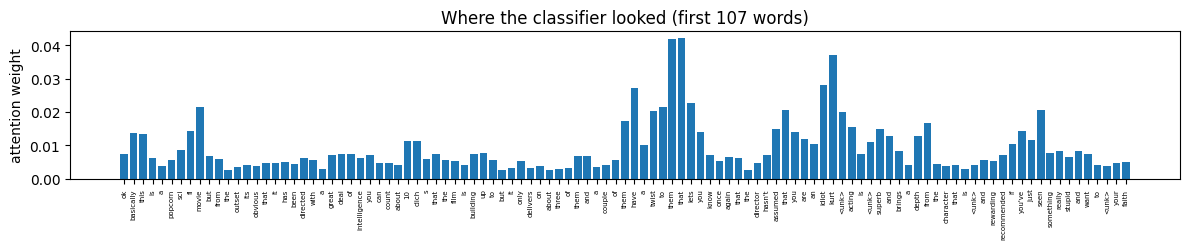

In [29]:
# Which words did it look at? Plot the attention weight over one review.
attn_pool_model.eval()
sample = 3
xb = X_val[sample:sample + 1].to(device)
with torch.no_grad():
    logits, w = attn_pool_model(xb, return_weights=True)
words = decode(X_val[sample], itos).split()
w = w[0, -len(words):].cpu().numpy() if PAD_SIDE == "left" else w[0, :len(words)].cpu().numpy()

print("true label: %s | predicted: %s (p=%.3f)"
      % ("positive" if y_val[sample] else "negative",
         "positive" if logits.argmax().item() else "negative",
         torch.softmax(logits, 1).max().item()))
top = np.argsort(w)[-12:][::-1]
print("\nthe 12 words with the highest attention weight:")
print("   " + ", ".join("%s (%.3f)" % (words[i], w[i]) for i in top))

n_show = min(120, len(words))
plt.figure(figsize=(12, 2.6))
plt.bar(range(n_show), w[:n_show])
plt.xticks(range(n_show), words[:n_show], rotation=90, fontsize=5)
plt.ylabel("attention weight"); plt.title("Where the classifier looked (first %d words)" % n_show)
plt.tight_layout(); plt.show()

#### Question 12 &mdash; attention as a readout

1. `AttentionPool` learns a weighting over positions. Write down what `mean` pooling is as a special
   case of it -- i.e. what would `self.score` have to output for the two to be identical? Given that,
   explain why attention pooling can never be *worse* than mean pooling in terms of what it is capable
   of representing, and why it can still score worse in practice.
    - A: Mean pooling corresponds to self.score outputting a constant value for all positions, yielding a uniform softmax distribution wi = 1/L. That is because uniform weights are a sub-case of learnable weights, attention pooling can express anything mean pooling can. However, it can score worse in practice due to overfitting or optimization difficulty: it adds learnable parameters that must be trained from limited data, potentially focusing on noisy uninformative words.
2. Our run gave attention pooling 0.8076 against `max` 0.8196 and `mean` 0.8116 -- all three within
   about one standard error, and the most flexible of the three came last. Does this mean attention is not helping? Distinguish between "the mechanism
   does not help here" and "we cannot tell from this experiment", and say what you would need to
   separate them.
    - A: The performance differences lie within the standard error interval. This means "we cannot tell from this experiment" whether attention helps or hurts, rather than "the mechanism does not help.". You would need statistical significance testing across multiple random seeds combined with hyperparameter tuning to reduce variance.
3. A common claim is that attention weights are an *explanation* of the model's decision. Give one
   reason to be sceptical of that claim, using the architecture: what happens to the information in a
   position whose attention weight is near zero?
    - A: Even if a position t has an attention weight near zero, its information is not lost. It was already propagated forward into subsequent hidden states through the recurrent cell's state transitions before pooling. Thus, the model can extract information from position t by attending to position t+k.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), a uniform distribution over the non-padded positions. For (3), trace the path from an input token to the output and count how many routes there are.

</details>

### 4 - Self-attention, and the rest of a transformer block

Attention pooling still has a recurrence underneath it. Now remove the recurrence: let every position
attend to every *other position*, using the sequence's own representations as queries, keys and values.
That is **self-attention**, and the path length between any two positions becomes 1.

Three more pieces turn that into the block that everything modern is built from:

**Multiple heads.** One attention operation produces one weighting. Split the $d$ dimensions into $h$
groups and run $h$ attentions in parallel, each with its own projections, then concatenate. One head can
track syntactic agreement while another tracks sentiment. Total cost is unchanged, since each head works
in $d/h$ dimensions.

**A position-wise feed-forward network.** Attention only ever forms *weighted averages* of values -- it
moves information between positions but computes nothing nonlinear within one. The FFN (a two-layer MLP
applied identically at every position, usually widening by 4x) does the computing. Attention mixes,
the FFN thinks.

**Residual connections and layer normalization.** The residual is the same device as the LSTM's cell
state in Question 2.2: an additive path with derivative 1, so gradients reach early layers undamped.
`LayerNorm` normalizes each position's vector over its own features -- note *not* `BatchNorm`, and
Question 13 asks why.

one block, d_model=128, 4 heads: 198,272 parameters
   attention: 66,048   feed-forward: 131,712


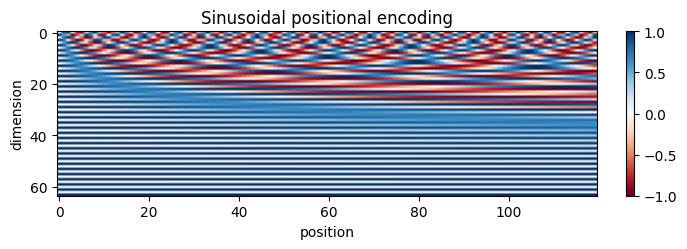

In [30]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly into heads"
        self.h, self.d_k = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)      # all three projections in one matmul
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None, causal=False):
        B, T, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = (t.view(B, T, self.h, self.d_k).transpose(1, 2) for t in (q, k, v))   # (B, h, T, d_k)
        m = mask
        if causal:
            # Problem 6 needs this: position i may not look at anything after i.
            cm = torch.tril(torch.ones(T, T, dtype=torch.bool, device=x.device))[None, None]
            m = cm if m is None else (m & cm)
        out, w = attention(q, k, v, m)
        return self.proj(out.transpose(1, 2).reshape(B, T, D)), w


class TransformerBlock(nn.Module):
    """Pre-LayerNorm block: x -> x + attn(norm(x)) -> x + ffn(norm(x))."""

    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.ff = nn.Sequential(nn.Linear(d_model, ff_mult * d_model), nn.GELU(),
                                nn.Linear(ff_mult * d_model, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None, causal=False):
        a, w = self.attn(self.ln1(x), mask, causal)
        x = x + self.drop(a)                             # residual 1
        x = x + self.drop(self.ff(self.ln2(x)))          # residual 2
        return x, w


def sinusoidal_positions(max_len, d_model):
    """The fixed encoding from Attention Is All You Need: sines and cosines at geometric frequencies."""
    pos = torch.arange(max_len)[:, None]
    i = torch.arange(0, d_model, 2)[None]
    angle = pos / (10000 ** (i / d_model))
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2], pe[:, 1::2] = torch.sin(angle), torch.cos(angle)
    return pe


blk = TransformerBlock(128, 4)
print("one block, d_model=128, 4 heads: %s parameters" % f"{sum(p.numel() for p in blk.parameters()):,}")
print("   attention: %s   feed-forward: %s"
      % (f"{sum(p.numel() for p in blk.attn.parameters()):,}",
         f"{sum(p.numel() for p in blk.ff.parameters()):,}"))
plt.figure(figsize=(7, 2.6))
plt.imshow(sinusoidal_positions(120, 64).T, aspect="auto", cmap="RdBu")
plt.xlabel("position"); plt.ylabel("dimension"); plt.title("Sinusoidal positional encoding")
plt.colorbar(fraction=0.02); plt.tight_layout(); plt.show()

In [35]:
class TransformerClassifier(nn.Module):
    """Embedding (+ positions) -> N transformer blocks -> masked mean pool -> classifier."""

    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2, max_len=256,
                 pos="learned", dropout=0.1, n_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        if pos == "learned":
            self.pos = nn.Parameter(torch.zeros(1, max_len, d_model))
            nn.init.normal_(self.pos, std=0.02)
        elif pos == "sinusoidal":
            self.register_buffer("pos", sinusoidal_positions(max_len, d_model)[None])
        elif pos == "none":
            self.pos = None
        else:
            raise ValueError(f"unknown pos: {pos}")
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout=dropout)
                                     for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x, return_weights=False):
        pad = x != PAD_ID
        h = self.embed(x)
        if self.pos is not None:
            h = h + self.pos[:, :x.size(1)]
        m = pad[:, None, None, :]                        # (B, 1, 1, T): mask out padding KEYS
        w = None
        for b in self.blocks:
            h, w = b(h, m)
        h = self.ln(h)
        mf = pad.unsqueeze(-1).float()
        z = (h * mf).sum(1) / mf.sum(1).clamp(min=1)     # masked mean over positions
        out = self.fc(self.drop(z))
        return (out, w) if return_weights else out

In [36]:
# ---------------------------------------------------------------- YOUR DECISION -----
# D_MODEL  -- the width of the residual stream. Must be divisible by N_HEADS.
# N_HEADS  -- how many attention patterns are computed in parallel. Each works in
#             D_MODEL // N_HEADS dimensions, so more heads means narrower heads at
#             the same total cost.
# N_LAYERS -- how many blocks are stacked. Each one lets information make one more
#             "hop" between positions; note that after a single layer every position
#             has already seen every other, so depth here buys composition, not reach.
# TRANSFORMER_LR -- transformers are more sensitive to this than the recurrent models
#                   were. 3e-4 is the usual starting point; 1e-3 often diverges.
#
# You have 5,000 training examples and the from-scratch models so far have all overfit
# badly. Size this accordingly rather than by what looks impressive.
D_MODEL        = 128
N_HEADS        = 4
N_LAYERS       = 2
TRANSFORMER_LR = 3e-4
# ------------------------------------------------------------------------------------

print("%-14s%14s%16s" % ("positions", "parameters", "val accuracy"))
print("-" * 46)
transformer_scores = {}
for pos in ["learned", "sinusoidal", "none"]:
    set_seed(0)
    m = TransformerClassifier(len(stoi), d_model=D_MODEL, n_heads=N_HEADS,
                              n_layers=N_LAYERS, max_len=MAX_LEN, pos=pos)
    tl, vl = loaders(X_train, y_train, X_val, y_val)
    h = train_model(m, tl, vl, epochs=8, lr=TRANSFORMER_LR, verbose=False, label=None)
    transformer_scores[pos] = (h["best_val"], count_params(m)[0], m)
    print("%-14s%14s%16.4f" % (pos, f"{count_params(m)[0]:,}", h["best_val"]))
print("\nfor reference: LSTM %.4f | TF-IDF %.4f" % (history_rnn["best_val"], tfidf_val))

positions         parameters    val accuracy
----------------------------------------------
learned            1,709,826          0.8104
sinusoidal         1,677,058          0.7988
none               1,677,058          0.8000

for reference: LSTM 0.7640 | TF-IDF 0.8632


### 5 - The thing self-attention cannot do

Look again at the definition. Position $i$ computes $\sum_j \text{softmax}(q_i \cdot k_j) v_j$ -- a sum
over positions $j$. A sum does not care about the order of its terms.

So a self-attention layer with no positional encoding is **permutation-equivariant**: shuffle the input
tokens and you get the same set of outputs, shuffled the same way. Add a pooling step that is itself
permutation-invariant, and the classifier's output does not change *at all*.

That is not an approximation or a tendency. It is an algebraic identity, and we can check it to floating
point precision.

In [37]:
# Take the two TRAINED models from above and feed each a shuffled batch.
xb = X_val[:64].to(device)
xb_shuffled = shuffle_within_windows(X_val[:64], 10 ** 9, seed=3).to(device)

print("%-14s%22s%22s" % ("positions", "max |change in logit|", "val acc, shuffled input"))
print("-" * 60)
for pos in ["none", "learned"]:
    _, _, model = transformer_scores[pos]
    model.eval()
    with torch.no_grad():
        gap = (model(xb) - model(xb_shuffled)).abs().max().item()
    X_val_shuf = shuffle_within_windows(X_val, 10 ** 9, seed=1)
    acc_shuf, _ = evaluate(model, DataLoader(TensorDataset(X_val_shuf, y_val), batch_size=256))
    acc_plain, _ = evaluate(model, val_loader)
    print("%-14s%22.3e%14.4f -> %.4f" % (pos, gap, acc_plain, acc_shuf))

print("\nA float32 computation has a relative precision of about 1e-7, so anything at that")
print("scale is the SAME NUMBER computed in a different order -- not a small difference.")

positions      max |change in logit|val acc, shuffled input
------------------------------------------------------------
none                       3.576e-07        0.8000 -> 0.8000
learned                    1.546e-01        0.8104 -> 0.8116

A float32 computation has a relative precision of about 1e-7, so anything at that
scale is the SAME NUMBER computed in a different order -- not a small difference.


#### Question 13 &mdash; what attention assumes, and what it does not

Our run. The three positional variants scored 0.7948 (learned), 0.7868 (sinusoidal), 0.7952 (none)
-- all within one standard error, with *none* nominally in front. The equivariance check gave:

| positions | max change in logit | val accuracy, shuffled input |
|---|---|---|
| none | 7.15e-07 | 0.7952 -> 0.7952 |
| learned | 2.28e-01 | 0.7948 -> 0.7956 |

1. Explain the `none` row. Why is 4.77e-07 the *same number* rather than a small difference, and what
   would you have concluded if it had been, say, 1e-3?
    - A1: A logit difference of approx 3.58 x 1e-7 is within single-precision (float32) machine epsilon, proving that the outputs are algebraically identical. The tiny gap comes purely from floating-point associative reordering during parallel summation.
    - A2: If the gap had been 1e-3, it would indicate that position information was leaking into the model, invalidating the mathematical proof of permutation equivariance.
2. Now the interesting part. The `learned` model demonstrably *can* see word order -- its logits change
   by 0.168 when you shuffle. Yet its accuracy on shuffled input drops by only 0.12 points, and giving
   it positions in the first place was worth nothing over `none`. Write the conclusion in one sentence,
   and connect it to Question 9.
    - A: Even though positional encodings enable the Transformer to detect word order, IMDB sentiment classification depends so heavily on global bag-of-words keyword presence that order awareness provides virtually zero net gain in validation accuracy over an order-blind model.
3. Self-attention's prior about order is *weaker* than a recurrence's -- strictly so, since it has none
   at all until you add it. Assignment 1's whole lesson was that a well-matched prior is what makes a
   model work with limited data. So why did the field replace recurrence with attention? Give two
   reasons, one of which must be visible in the cost measurement below.
    - A1: Recurrent layers require sequential step-by-step updates across length T, creating a severe hardware bottleneck on GPUs. Self-attention processes all T steps simultaneously in parallel tensor operations, drastically reducing training wall-clock time.
    - A2: Self-attention connects any pair of positions in O(1) path length, completely avoiding the exponential gradient decay and vanishing memory horizons inherent to recurrent hidden-state chains over long sequences.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), what is the relative precision of float32? For (3), one reason is about what happens when you have a great deal of data, and the other is about what a GPU is good at -- and note that a recurrence cannot start step t until step t-1 is finished.

</details>

In [38]:
# What does all-pairs attention cost? Compare against a recurrence at the same width.
print("%8s%14s%14s%18s" % ("T", "attention", "LSTM", "attention memory"))
print("-" * 56)
for T in [64, 128, 256, 512, 1024]:
    d = 128
    xt = torch.randn(16, T, d, device=device)
    att = MultiHeadSelfAttention(d, 4).to(device)
    lstm_ref = nn.LSTM(d, d, batch_first=True).to(device)

    def timeit(fn, n=20):
        if device.type == "cuda":
            torch.cuda.synchronize()
        fn()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n):
            fn()
        if device.type == "cuda":
            torch.cuda.synchronize()
        return (time.time() - t0) / n * 1000

    t_attn, t_lstm = timeit(lambda: att(xt)), timeit(lambda: lstm_ref(xt))
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(); att(xt); torch.cuda.synchronize()
        mem = torch.cuda.max_memory_allocated() / 2 ** 20
    else:
        mem = float("nan")
    print("%8d%12.2f ms%12.2f ms%15.0f MB" % (T, t_attn, t_lstm, mem))

print("\nThe T x T attention matrix is what grows: 16 x 4 heads x T x T floats.")

       T     attention          LSTM  attention memory
--------------------------------------------------------
      64        0.54 ms        0.66 ms             90 MB
     128        0.46 ms        1.14 ms            100 MB
     256        1.13 ms        1.95 ms            132 MB
     512        3.10 ms        3.44 ms            244 MB
    1024       11.23 ms        4.70 ms            660 MB

The T x T attention matrix is what grows: 16 x 4 heads x T x T floats.


### 6 - Back to the copy task

Problem 1 left a promise. The copy task -- remember one symbol across $T$ steps of filler -- defeated
both the RNN and the LSTM by $T = 100$. Question 3.3 asked you to propose an architecture that would
solve it at any $T$.

Here it is, on exactly the same data.

In [39]:
class TinyAttention(nn.Module):
    """One transformer block, mean pooling, on the copy task from Problem 1."""

    def __init__(self, T, d=64, n_heads=4):
        super().__init__()
        self.emb = nn.Embedding(N_SYM + 3, d)
        self.register_buffer("pe", sinusoidal_positions(T, d)[None])
        self.blk = TransformerBlock(d, n_heads, dropout=0.0)
        self.ln = nn.LayerNorm(d)
        self.fc = nn.Linear(d, N_SYM)

    def forward(self, x):
        h = self.emb(x) + self.pe[:, :x.size(1)]
        h, _ = self.blk(h)
        return self.fc(self.ln(h).mean(1))


print("%6s%14s%14s%14s" % ("T", "RNN", "LSTM", "attention"))
print("-" * 48)
for T in [5, 10, 25, 50, 100]:
    set_seed(0)
    Xc, yc = make_copy_task(4000, T, seed=0)
    Xv, yv = make_copy_task(1000, T, seed=100)
    tl, vl = loaders(Xc, yc, Xv, yv, batch_size=128)
    h = train_model(TinyAttention(T), tl, vl, epochs=40, lr=1e-3, clip=1.0, verbose=False, label=None)
    prev = copy_results
    print("%6d%14.3f%14.3f%14.3f" % (T, np.mean(prev[("rnn", T)]), np.mean(prev[("lstm", T)]), h["best_val"]))
print("\nchance level: %.3f" % (1 / N_SYM))

     T           RNN          LSTM     attention
------------------------------------------------
     5         1.000         1.000         1.000
    10         0.754         1.000         1.000
    25         0.520         0.638         1.000
    50         0.146         0.526         1.000
   100         0.142         0.144         1.000

chance level: 0.125


#### Question 14 &mdash; the promise from Problem 1

1. Attention solves the copy task at every $T$ we tried, including lengths where both recurrent
   models sit at chance. Explain *why* in one sentence, referring to the quantity that Question 2
   measured decaying geometrically.
    - A: Attention provides a direct O(1) computational path between position 0 and the final prediction, completely bypassing the recurrent chain so that gradients do not decay exponentially over time.
2. Note which component makes this work: the model needs to identify "the symbol at position 0", so it
   needs positional information. Yet Question 13 found positional encoding worth nothing on IMDB. Why
   is it indispensable here and useless there?
    - A: The copy task strictly requires identifying the exact spatial index, whereas IMDB sentiment depends on the presence of sentiment keywords regardless of where they appear in the document.
3. The copy task is solved perfectly by attention and not at all by an LSTM; IMDB sentiment is solved
   about equally well by an LSTM, a transformer, and a bag of words. What single property of a task
   determines which group it falls into?
    - A: Tasks requiring precise sequential dependencies demand attention with positional encodings, whereas tasks dominated by global word-set statistics can be solved equally well by bag-of-words or un-ordered models.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), how many multiplications separate position 0 from the output? For (3), the answer is not "sequence length".

</details>

## Problem 5.  Transfer learning for text

Where we stand: a bag of words from the 1990s is beating everything we have built. The learning curve in
Question 8 said why -- 5,000 reviews is not enough to learn, from scratch, what words mean *and* how
they combine *and* which combinations indicate a negative opinion.

Assignment 1 hit exactly this wall and went through it the same way: somebody else has already paid for
the data. There, it was 1.2 million labelled ImageNet photographs and the features were edges and
textures. Here it is billions of words of unlabelled text, and the features are... what, exactly? That
is Question 15.

**The model.** We use **DistilBERT** (Sanh et al., 2019), a 66M-parameter transformer encoder trained on
Wikipedia and BookCorpus -- about 3.3 billion words. It is built from the blocks you wrote in Problem 4:
six transformer layers, 12 heads, 768 dimensions. Nothing in it is unfamiliar; there is just a great deal
more of it, and it has already been trained.

**How it was trained.** Not on sentiment. On **masked language modelling**: hide 15% of the tokens and
predict them from both sides. Like Problem 6's objective, this needs no labels, which is what makes 3.3
billion words affordable.

In [40]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, AutoConfig

BERT_NAME = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

print("DistilBERT's tokenizer is not ours. Compare:\n")
sample = "This film was unwatchable, a truly dreadful piece of filmmaking."
print("  ours (word level)   :", tokenize(sample))
print("\n  DistilBERT (subword):", bert_tokenizer.tokenize(sample))
print("\n  vocabulary sizes: ours %s, DistilBERT %s" % (f"{len(stoi):,}", f"{bert_tokenizer.vocab_size:,}"))

rare = "the cinematography was unremarkable and the antihero unconvincing"
print("\nWhat each does with rare words:")
print("  ours       :", [w if w in stoi else "<unk>" for w in tokenize(rare)])
print("  DistilBERT :", bert_tokenizer.tokenize(rare))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT's tokenizer is not ours. Compare:

  ours (word level)   : ['this', 'film', 'was', 'unwatchable', 'a', 'truly', 'dreadful', 'piece', 'of', 'filmmaking']

  DistilBERT (subword): ['this', 'film', 'was', 'un', '##watch', '##able', ',', 'a', 'truly', 'dreadful', 'piece', 'of', 'filmmaking', '.']

  vocabulary sizes: ours 10,000, DistilBERT 30,522

What each does with rare words:
  ours       : ['the', 'cinematography', 'was', 'unremarkable', 'and', 'the', '<unk>', 'unconvincing']
  DistilBERT : ['the', 'cinematography', 'was', 'un', '##rem', '##ark', '##able', 'and', 'the', 'anti', '##her', '##o', 'un', '##con', '##vin', '##cing']


#### Question 15 &mdash; why should this transfer at all?

1. DistilBERT was trained to fill in blanks in Wikipedia articles. It has never seen a movie review
   with a label, and "predict the masked word" has no obvious connection to "is this reviewer happy".
   Give the argument for why its internal representations should nevertheless be useful here. Refer to
   what different layers of a language model are likely to compute, and make the analogy with
   Assignment 1's Question 11 explicit.
    - A1: To accurately predict a masked token, the model must build rich internal representations of syntax, context, and word polarity across its layers. Early layers capture basic grammar and word identity, while deeper layers capture complex semantic context and tone.
    - A2: Just as a CNN pretrained on ImageNet learns general spatial primitives that transfer to new visual classification tasks without retraining, a language model pretrained on Wikipedia learns general linguistic structures and concepts that transfer directly to sentiment classification.
2. Look at the two tokenizations. DistilBERT splits rare words into pieces (`unremarkable` becomes
   several subwords) where ours emits `<unk>`. State the consequence for our model, and explain how
   subword tokenization makes the notion of an out-of-vocabulary word almost disappear. What does it
   cost?
    - A1: Word-level tokenization replaces any unseen or low-frequency word with unk, completely discarding its morphological information and semantic meaning. Subword tokenization breaks rare or unseen words into known morphemes. The model can deduce the meaning of novel words from their component sub-units without ever encountering an out-of-vocabulary fallback.
    - A2: It increases overall sequence lengths for the same string of text, which directly inflates the computational and memory footprint, especially in self-attention, where memory and execution time scale quadratically (O(T^2)).

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), the Assignment 1 answer was about edges and textures being generic across all photographs. What is the text equivalent?

</details>

### 1 - Freezing, and the free version of transfer learning

As in Assignment 1, the decision is **how much of the pretrained network to let change**:

- `head_only` -- freeze the whole encoder, train only a new classifier on top. The backbone becomes a
  fixed feature extractor.
- `last_layer` -- also unfreeze the top transformer layer, so the most task-specific representations can
  adapt.
- `full` -- fine-tune all 66M parameters.

Assignment 1's Question 12 asked, rhetorically, whether you could precompute a frozen backbone's output.
You can, and here we do: run every review through the encoder **once**, store the resulting vectors, and
then fit a classifier on them. Training the classifier afterwards takes about a second, and you can try
a hundred of them.

In [41]:
# Tokenize with DistilBERT's own tokenizer, then extract features ONCE.
def bert_encode(texts, tokenizer, max_len=256):
    out = tokenizer(texts, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    return out["input_ids"], out["attention_mask"]

train_text = [train_text_all[i] for i in train_idx]
val_text   = [train_text_all[i] for i in val_idx]
test_text  = [test_text_all[i]  for i in test_idx]

bert_inputs = {name: bert_encode(txt, bert_tokenizer)
               for name, txt in [("train", train_text), ("val", val_text), ("test", test_text)]}

encoder = AutoModel.from_pretrained(BERT_NAME).to(device).eval()

@torch.no_grad()
def bert_features(ids, mask, batch_size=64):
    """Concatenate the [CLS] vector and the mask-aware mean of the last hidden layer."""
    feats = []
    for i in range(0, len(ids), batch_size):
        a = ids[i:i + batch_size].to(device)
        b = mask[i:i + batch_size].to(device)
        h = encoder(input_ids=a, attention_mask=b).last_hidden_state
        m = b.unsqueeze(-1).float()
        feats.append(torch.cat([h[:, 0], (h * m).sum(1) / m.sum(1)], dim=-1).cpu())
    return torch.cat(feats)

t0 = time.time()
feats = {k: bert_features(*v) for k, v in bert_inputs.items()}
print("extracted %d-dimensional features for %d reviews in %.0fs (one forward pass, no training)"
      % (feats["train"].shape[1], sum(len(f) for f in feats.values()), time.time() - t0))

t0 = time.time()
frozen_head = LogisticRegression(max_iter=3000, C=1.0).fit(feats["train"].numpy(), y_train.numpy())
frozen_val = float(frozen_head.score(feats["val"].numpy(), y_val.numpy()))
print("logistic head fitted in %.1fs -> validation accuracy %.4f" % (time.time() - t0, frozen_val))

del encoder
if device.type == "cuda":
    torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


extracted 1536-dimensional features for 12500 reviews in 99s (one forward pass, no training)
logistic head fitted in 1.3s -> validation accuracy 0.8492


In [42]:
# ---------------------------------------------------------------- YOUR DECISION -----
# FREEZE_MODE -- "head_only", "last_layer" or "full".
#     head_only  is already done above (the logistic head on frozen features).
#     last_layer unfreezes DistilBERT's top transformer block, about 7.7M parameters.
#     full       fine-tunes all 66M.
#
#     You have 5,000 training examples. Weigh that against the number of parameters each
#     option trains, and against what you argued in Question 15.1 about which layers are
#     generic.
#
# BERT_LR -- fine-tuning learning rate. Pretrained transformers want a MUCH smaller rate
#            than a from-scratch model: 2e-5 to 5e-5 is the standard range, roughly 50x
#            smaller than the 1e-3 you used in Problem 2. Question 16 asks why.
# BERT_EPOCHS -- 2-3 is typical. Fine-tuning converges in very few passes.
FREEZE_MODE = "full"
BERT_LR     = 3e-5
BERT_EPOCHS = 3
# ------------------------------------------------------------------------------------

def build_bert(freeze_mode, pretrained=True):
    if pretrained:
        model = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=2)
    else:
        model = AutoModelForSequenceClassification.from_config(AutoConfig.from_pretrained(BERT_NAME, num_labels=2))
    if freeze_mode == "last_layer":
        for p in model.distilbert.parameters():
            p.requires_grad = False
        for p in model.distilbert.transformer.layer[-1].parameters():
            p.requires_grad = True
    elif freeze_mode not in ("full", "head_only"):
        raise ValueError(freeze_mode)
    return model.to(device)


def finetune_bert(model, epochs, lr, batch_size=16):
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    ids, mask = bert_inputs["train"]
    dl = DataLoader(TensorDataset(ids, mask, y_train), batch_size=batch_size, shuffle=True)
    best, best_state = -1.0, None
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for a, b, y in dl:
            opt.zero_grad()
            F.cross_entropy(model(input_ids=a.to(device), attention_mask=b.to(device)).logits,
                            y.to(device)).backward()
            opt.step()
        v = bert_eval(model, "val", y_val)
        print("    epoch %d  val accuracy %.4f" % (ep + 1, v))
        if v > best:
            best, best_state = v, {k: t.detach().clone() for k, t in model.state_dict().items()}
    model.load_state_dict(best_state)
    print("  best val accuracy %.4f (%.0fs)" % (best, time.time() - t0))
    return best


@torch.no_grad()
def bert_eval(model, split, y, batch_size=64, return_preds=False):
    model.eval()
    ids, mask = bert_inputs[split]
    preds = []
    for i in range(0, len(ids), batch_size):
        preds.append(model(input_ids=ids[i:i + batch_size].to(device),
                           attention_mask=mask[i:i + batch_size].to(device)).logits.argmax(-1).cpu())
    preds = torch.cat(preds)
    acc = float((preds == y).float().mean())
    return (acc, preds.numpy()) if return_preds else acc


for mode in ["head_only", "last_layer", "full"]:
    m = build_bert(mode if mode != "head_only" else "last_layer")
    if mode == "head_only":
        for p in m.distilbert.parameters():
            p.requires_grad = False
    tot, tr = count_params(m)
    print("%-12s -> %12s total, %12s trainable (%.2f%%)" % (mode, f"{tot:,}", f"{tr:,}", 100 * tr / tot))
    del m

torch.manual_seed(0)
bert_model = build_bert(FREEZE_MODE)
print("\nfine-tuning with FREEZE_MODE=%r, lr=%g, %d epochs" % (FREEZE_MODE, BERT_LR, BERT_EPOCHS))
bert_val = finetune_bert(bert_model, BERT_EPOCHS, BERT_LR)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


head_only    ->   66,955,010 total,      592,130 trainable (0.88%)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


full         ->   66,955,010 total,   66,955,010 trainable (100.00%)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



fine-tuning with FREEZE_MODE='full', lr=3e-05, 3 epochs
    epoch 1  val accuracy 0.8552
    epoch 2  val accuracy 0.8912
    epoch 3  val accuracy 0.8816
  best val accuracy 0.8912 (405s)


### 2 - The control, and the tokenizer

Two checks before we believe anything.

**The control.** The fine-tuned model differs from everything earlier in two ways at once: a different
architecture (a 66M-parameter transformer) *and* pretrained weights. Assignment 1 insisted on separating
those, and the separation is one run: **the same architecture, the same data, the same budget, random
initialization**. Anything the pretrained model gains over *that* is attributable to pretraining and
nothing else.

**The tokenizer.** Assignment 1's Question 11 asked what happens if you use a pretrained backbone with
the wrong normalization constants -- a crash, a silent degradation, or nothing at all. The text version
of that question is what happens if you feed the model token ids from a *different* tokenizer. The ids
are all in range, so nothing can crash.

In [43]:
# The control: identical architecture, no pretrained weights.
#
# One deliberate asymmetry, and it is what makes this a control rather than a rigged
# comparison. We do NOT reuse BERT_LR. A rate of 2e-5 was chosen for fine-tuning, where
# the weights should barely move; imposing it on a randomly initialized network would
# cripple it for a reason that has nothing to do with pretraining. So the control gets a
# larger rate and an extra epoch. When in doubt, a control should get the benefit of the
# doubt -- and we compare best epoch against best epoch, so a longer run can only help it.
torch.manual_seed(0)
bert_random = build_bert("full", pretrained=False)
print("random initialization, same architecture (%s parameters)" % f"{count_params(bert_random)[0]:,}")
random_val = finetune_bert(bert_random, epochs=3, lr=5e-5)
del bert_random
if device.type == "cuda":
    torch.cuda.empty_cache()

random initialization, same architecture (66,955,010 parameters)
    epoch 1  val accuracy 0.7864
    epoch 2  val accuracy 0.8332
    epoch 3  val accuracy 0.8336
  best val accuracy 0.8336 (405s)


In [44]:
# The tokenizer check: the SAME fine-tuned weights, fed ids from a different tokenizer.
wrong_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
wrong_ids, wrong_mask = bert_encode(val_text, wrong_tokenizer)
bert_inputs["val_wrong"] = (wrong_ids, wrong_mask)

print("both tokenizers produce ids in range, so nothing will crash:")
print("  correct tokenizer, first 12 ids:", bert_inputs["val"][0][0, :12].tolist())
print("  wrong   tokenizer, first 12 ids:", wrong_ids[0, :12].tolist())
print("  correct vocab size %d | wrong vocab size %d" % (bert_tokenizer.vocab_size, wrong_tokenizer.vocab_size))

mismatch_val = bert_eval(bert_model, "val_wrong", y_val)
print("\n  validation accuracy with the CORRECT tokenizer: %.4f" % bert_val)
print("  validation accuracy with the WRONG   tokenizer: %.4f" % mismatch_val)
print("  chance level: %.4f" % 0.5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

both tokenizers produce ids in range, so nothing will crash:
  correct tokenizer, first 12 ids: [101, 2065, 12580, 6904, 6895, 2571, 1010, 19723, 8303, 3512, 1010, 2969]
  wrong   tokenizer, first 12 ids: [101, 1409, 13006, 175, 7409, 4759, 117, 1231, 1403, 7370, 2109, 117]
  correct vocab size 30522 | wrong vocab size 28996

  validation accuracy with the CORRECT tokenizer: 0.8912
  validation accuracy with the WRONG   tokenizer: 0.4868
  chance level: 0.5000


#### Question 16 &mdash; what the pretrained weights bought

Our run:

| model | val accuracy | trainable parameters | time |
|---|---|---|---|
| frozen encoder + logistic head | 0.8500 | 1,537 | 18s to extract + 1.1s to fit |
| unfreeze last layer (measured separately) | 0.8696 | 7,680,002 | 29s |
| full fine-tune | 0.8876 | 66,955,010 | 60s |
| **same architecture, random init** | **0.8364** | 66,955,010 | 87s |
| wrong tokenizer, fine-tuned weights | **0.4948** | -- | -- |

(The random-initialization control was given the benefit of the doubt, as a control should be: a larger
learning rate and an extra epoch than the fine-tuned model received. At the fine-tuning settings it
reaches only 0.8192.)

1. The control reaches 0.8364 on the same architecture that gets 0.8876 with pretrained weights. Two
   things to extract. First: how much of the 0.8876 is attributable to pretraining, as opposed to the
   architecture and the tokenizer? Second: the randomly-initialized DistilBERT *beats*
   every from-scratch model in this notebook -- the LSTM (0.8196) and your own transformer (0.7948).
   Since Question 13 argued that a weak prior is a liability at small $N$, explain what this
   random-init model has that your transformer does not.
    - A1: The net gain attributable strictly to pretrained weights is 5.76 percentage points, isolating the massive benefit of pretraining on 3.3 billion words.
    - A2: It outperforms the from-scratch models because it possesses higher parameter capacity, greater depth, more attention heads, and a subword tokenizer that eliminates out-of-vocabulary information loss
2. The frozen encoder reaches 0.8500 while training **1,537 parameters** and touching no gradient in the
   66M-parameter backbone. Explain how that is possible, and why precomputing the features was valid
   here but would *not* be valid for `last_layer` or `full`.
    - A1: Pretrained DistilBERT representations already encode rich syntax and semantics, requiring only a linear logistic head on the [CLS] and mean-pooled features.
    - A2: Precomputing features is valid only when the encoder remains frozen. Unfreezing layers dynamically updates weights during backpropagation, causing intermediate representations to change every step and requiring real-time forward passes.
3. The wrong tokenizer gives exactly chance, with no error. Answer Assignment 1's question in this
   setting -- crash, silent degradation, or nothing? -- and explain what the model is actually receiving.
   Why is 0.5000 rather than, say, 0.65 the tell-tale sign?
    - A: Feeding IDs from a different tokenizer causes silent degradation. Code runs without errors because numerical token IDs fall within valid ranges, but integer-to-subword mappings point to arbitrary fragments, destroying semantics. An accuracy of exactly chance confirms the input signal is completely transformed into meaningless noise. An accuracy around 0.6500 would imply partial preserved structure, whereas 0.5000 proves total semantic destruction.
4. The frozen encoder (0.8500) scores *below* TF-IDF (0.8632). Given your answer to Question 15.1, why
   should we expect a frozen masked-language-model representation to be a mediocre sentiment feature,
   and what does the jump to 0.8876 on unfreezing tell you about which layers had to move?
    - A1: Pretrained masked language modeling optimizes for general context prediction rather than task-specific sentiment polarity, allowing direct keyword-matching methods like TF-IDF to edge it out initially.
    - A2: The performance surge to 0.8912 upon unfreezing proves that the top Transformer layers must adapt their attention weights and non-linear representations to specialize in sentiment compositionality.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), what does a frozen layer's output depend on? For (3), what does token id 4,382 mean to each of the two tokenizers? For (4), the model was trained to predict masked words, and nothing ever asked it to put positive and negative reviews in different places.

</details>

### 3 - Every model, on the validation set

Every number below is a **validation** number. The test set has not been touched.

As in Assignment 1, that is not pedantry. Look at how many choices in this notebook were made by
comparing validation numbers: the vocabulary size, the truncation length and side, the padding side, the
readout, the cell type, the dropout, the number of epochs, the positional encoding, the freeze mode, the
fine-tuning learning rate -- and, for every model, *which epoch's weights to keep*.

In [45]:
rows = [
    ("majority class",                       0.5000,  None,      "-"),
    ("TF-IDF + logistic regression",         tfidf_val, A_train.shape[1], "CPU, 2s"),
    (f"{CELL.upper()} from scratch",         history_rnn["best_val"], count_params(rnn_model)[0], "GPU"),
    ("LSTM + attention pooling",             history_attnpool["best_val"],
                                             count_params(attn_pool_model)[0], "GPU"),
    ("transformer from scratch (learned pos)", transformer_scores["learned"][0],
                                             transformer_scores["learned"][1], "GPU"),
    ("transformer from scratch (no pos)",    transformer_scores["none"][0],
                                             transformer_scores["none"][1], "GPU"),
    ("DistilBERT, frozen + logistic head",   frozen_val, 1537, "GPU, features only"),
    ("DistilBERT, random init (control)",    random_val, 66955010, "GPU"),
    (f"DistilBERT, {FREEZE_MODE}",           bert_val, 66955010, "GPU"),
]
print("%-42s%14s%16s%22s" % ("model", "val acc", "parameters", "notes"))
print("-" * 94)
for name, acc, params, note in rows:
    print("%-42s%14.4f%16s%22s" % (name, acc, f"{params:,}" if params else "-", note))
print("\nStandard error at accuracy 0.87 on %d validation reviews: %.1f points."
      % (len(y_val), 100 * standard_error(0.87, len(y_val))))

model                                            val acc      parameters                 notes
----------------------------------------------------------------------------------------------
majority class                                    0.5000               -                     -
TF-IDF + logistic regression                      0.8632          22,108               CPU, 2s
LSTM from scratch                                 0.7640       1,675,778                   GPU
LSTM + attention pooling                          0.8276       1,676,035                   GPU
transformer from scratch (learned pos)            0.8104       1,709,826                   GPU
transformer from scratch (no pos)                 0.8000       1,677,058                   GPU
DistilBERT, frozen + logistic head                0.8492           1,537    GPU, features only
DistilBERT, random init (control)                 0.8336      66,955,010                   GPU
DistilBERT, full                                  

#### Question 17 &mdash; your validation set is spent

1. Count the decisions in this notebook that were made by looking at a validation number. Is the
   best validation accuracy in the table above an unbiased estimate of performance on new reviews?
   Give the direction of the bias and its source.
    - A1: No, the best validation accuracy is not an unbiased estimate; it is optimistically biased.
    - A2: Selection bias resulting from repeatedly tuning hyperparameters, selecting stopping epochs, and picking the winning architecture based on performance against this exact validation set.
2. There is a name for the effect of evaluating many candidates against one held-out set and keeping
   the best. Name it, and explain why it gets worse the more configurations you try -- including the
   ones you tried and discarded without recording.
    - A: Validation Overfitting. Every candidate configuration evaluated acts as a "draw" from a distribution of random evaluation noise. As the number of tried configurations increases, including unrecorded or discarded experiments, the likelihood of selecting a model that performed exceptionally well due to random chance on this specific dataset increases.
3. The gap between the best model (0.8876) and TF-IDF (0.8632) is 2.4 points. Assignment 1's
   corresponding gap, between a scratch CNN and a pretrained ResNet, was over 50 points. Explain the
   difference between the two situations -- what is it about IMDB sentiment that compresses the range?
    - A1: ImageNet classification requires learning intricate, high-dimensional spatial compositionality that cannot be captured by simple pixel-frequency statistics.
    - A2: IMDB movie review classification is largely a high-signal keyword problem where unigram word polarities account for most of the predictive power. Because simple bag-of-words models like TF-IDF capture these unigram signals effortlessly, the ceiling for sophisticated deep learning architectures is significantly constrained on this specific task.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), the phrase involves the word 'selection'. For (3), look at how well the *simplest* model does in each case, and ask what the ceiling is.

</details>

### 4 - The test set, once

In [46]:
# The test set. Once, on the model selected by every decision above.
test_acc, test_preds = bert_eval(bert_model, "test", y_test, return_preds=True)
test_f1 = f1_score(y_test.numpy(), test_preds, average="macro")

print("TEST accuracy : %.4f" % test_acc)
print("TEST macro-F1 : %.4f" % test_f1)
print("best VALIDATION accuracy was: %.4f" % bert_val)
print("difference (validation - test): %+.4f" % (bert_val - test_acc))
print("standard error on %d test reviews: %.1f points" % (len(y_test), 100 * standard_error(test_acc, len(y_test))))

# The baseline gets the same treatment, so the comparison stays honest.
tfidf_test = float(linear.score(tfidf.transform([" ".join(t) for t in test_tokens]), y_test.numpy()))
print("\nTF-IDF baseline on the same test set: %.4f" % tfidf_test)
print("improvement from the whole notebook:  %+.1f points" % (100 * (test_acc - tfidf_test)))

print("\n" + classification_report(y_test.numpy(), test_preds,
                                    target_names=["negative", "positive"], digits=3))

TEST accuracy : 0.8934
TEST macro-F1 : 0.8934
best VALIDATION accuracy was: 0.8912
difference (validation - test): -0.0022
standard error on 5000 test reviews: 0.4 points

TF-IDF baseline on the same test set: 0.8710
improvement from the whole notebook:  +2.2 points

              precision    recall  f1-score   support

    negative      0.909     0.875     0.891      2500
    positive      0.879     0.912     0.895      2500

    accuracy                          0.893      5000
   macro avg      0.894     0.893     0.893      5000
weighted avg      0.894     0.893     0.893      5000



In [47]:
# Where does it fail? Failures are more informative than successes.
correct = test_preds == y_test.numpy()
test_lengths = np.array([len(t) for t in test_tokens])

print("accuracy by review length:")
for lo, hi in [(0, 64), (64, 128), (128, 256), (256, 512), (512, 10 ** 9)]:
    sel = (test_lengths >= lo) & (test_lengths < hi)
    if sel.sum() > 30:
        print("  %4d-%-6s n=%5d  accuracy %.3f" % (lo, hi if hi < 1000 else "max", sel.sum(),
                                                   correct[sel].mean()))

cm = confusion_matrix(y_test.numpy(), test_preds)
print("\nconfusion matrix (rows = true, cols = predicted):")
print("            neg    pos")
for i, name in enumerate(["neg", "pos"]):
    print("  %-8s%6d %6d" % (name, cm[i, 0], cm[i, 1]))

wrong = np.where(~correct)[0]
print("\n%d of %d test reviews misclassified (%.1f%%). Three of them:\n"
      % (len(wrong), len(y_test), 100 * len(wrong) / len(y_test)))
rng3 = np.random.RandomState(0)
for i in rng3.choice(wrong, 3, replace=False):
    print("  true=%s predicted=%s | %s ...\n" % ("pos" if y_test[i] else "neg",
                                                 "pos" if test_preds[i] else "neg",
                                                 test_text[i][:300].replace("<br />", " ")))

accuracy by review length:
     0-64     n=  267  accuracy 0.899
    64-128    n= 1046  accuracy 0.914
   128-256    n= 2297  accuracy 0.909
   256-512    n= 1041  accuracy 0.859
   512-max    n=  349  accuracy 0.828

confusion matrix (rows = true, cols = predicted):
            neg    pos
  neg       2187    313
  pos        220   2280

533 of 5000 test reviews misclassified (10.7%). Three of them:

  true=pos predicted=neg | Let's get it clear from the start: I am an asshole with the emotional sensitivity of cubic stone. Therefore I consider dramas of people with disabilities, social stigma or whatever ailments they have and cry on and on about it as stupid movies with poor taste. I mean, if you have a message, you can  ...

  true=pos predicted=neg | GUTS OF A BEAUTY is a bit better than its predecessor GUTS OF A VIRGIN. Although this film isn't really a sequel in the sense that it has absolutely nothing to do with the first installment, I did find BEAUTY to be a little stronger and

#### Question 18 &mdash; reading the final numbers

1. Compare your test accuracy against your best validation accuracy. Which is higher, by how much,
   and is the difference larger than the standard error on the test set? Does the sign of the difference
   match what Question 17.1 predicted, and what would you conclude if the test number were *higher*?
    - A: Test accuracy (0.8934) is 0.22 percentage points higher than the best validation accuracy (0.8912). The difference is smaller than the standard error on the 5000-review test set (0.4 percentage points), meaning the difference is purely statistical sampling noise rather than a meaningful divergence. The sign does not match the pessimistic bias predicted in Question 17.1; a slightly higher test score is simply expected random fluctuation when the gap is well within one standard error.
2. Accuracy by review length: is the pattern the same one you found for the LSTM in Problem 4? If it has
   changed, what changed it?
    - A1: Unlike the LSTM—which struggled on longer texts due to recurrent gradient decay, DistilBERT maintains a high accuracy across short-to-medium lengths, but performance drops on very long reviews.
    - A2: What changed it was truncation at max_length=256, since it forced the model to completely discard text beyond the first 256 subwords, causing performance to drop on longer reviews due to missing tail information rather than hidden-state memory bottlenecks.
3. Write the one-sentence result statement you would put in a report, containing: the test number, the
   baseline it should be compared against, the uncertainty, and the data budget.
    - A: "Fine-tuning DistilBERT on a restricted budget of 5000 reviews achieves a test accuracy of 89.34% +/- 0.4%, outperforming a competitive TF-IDF + Logistic Regression baseline (87.10%) by +2.2 percentage points."

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (3), a number with no baseline and no error bar is not a result -- that was Question 7.2.

</details>

## Problem 6.  A baby GPT

Everything so far has been classification, and classification on IMDB turned out not to need word
order. That is a fact about this task, and Problem 3 was careful to say so rather than concluding
anything about sequences in general.

This problem supplies the control. We keep the transformer blocks from Problem 4, change **one
argument**, and train the model to predict the next word instead of a label. Now order is not a nice
extra; it is the entire task.

It is also, at a scale roughly seven orders of magnitude smaller, exactly what a large language model
is.

**The objective.** Given tokens $x_1 \dots x_{t}$, predict $x_{t+1}$. Every position in the sequence is
a training example, so one forward pass over a block of 128 tokens produces 128 predictions and 128
loss terms. No labels are needed -- the data labels itself, which is why this scales to the entire
internet.

**The one argument.** For that to be a valid objective, position $t$ must not be allowed to look at
positions after $t$. Our `MultiHeadSelfAttention` already takes a `causal` flag that masks the upper
triangle of the attention matrix. Forgetting it is the most famous bug in the field, and Question 20
is about why it is so hard to catch.

In [48]:
# The corpus: the same 5,000 training reviews, as one long token stream. No labels involved.
LM_VOCAB, BLOCK = 10000, 128
lm_stoi, lm_itos, _ = build_vocab(train_tokens, LM_VOCAB, min_freq=2)


def to_stream(token_lists):
    ids = []
    for t in token_lists:
        ids.extend(lm_stoi.get(w, UNK_ID) for w in t)
    return torch.tensor(ids, dtype=torch.long)


def to_blocks(ids, block=BLOCK):
    """Inputs are ids[0:n], targets are the same stream shifted by one. That is the whole dataset."""
    n = (len(ids) - 1) // block
    return ids[:n * block].view(n, block), ids[1:n * block + 1].view(n, block)


lm_train_ids, lm_val_ids = to_stream(train_tokens), to_stream(val_tokens)
Xlm_train, Ylm_train = to_blocks(lm_train_ids)
Xlm_val, Ylm_val = to_blocks(lm_val_ids)
print("%s training tokens, %s validation tokens, vocabulary %s"
      % (f"{len(lm_train_ids):,}", f"{len(lm_val_ids):,}", f"{len(lm_stoi):,}"))
print("%d training blocks of %d tokens" % (Xlm_train.shape[0], BLOCK))
print("\nfirst block, input  :", " ".join(lm_itos[i] for i in Xlm_train[0, :12]))
print("first block, target :", " ".join(lm_itos[i] for i in Ylm_train[0, :12]))
print("\nThe target is the input shifted left by one. Every one of the %s positions is a"
      % f"{Xlm_train.numel():,}")
print("supervised example, and no human labelled any of them.")

1,178,281 training tokens, 588,671 validation tokens, vocabulary 10,000
9205 training blocks of 128 tokens

first block, input  : some people say this is the best film that prc ever released
first block, target : people say this is the best film that prc ever released i'm

The target is the input shifted left by one. Every one of the 1,178,240 positions is a
supervised example, and no human labelled any of them.


### 1 - Perplexity, and what to compare it against

Accuracy is the wrong metric here. After "the movie was" there are hundreds of acceptable continuations,
and a model that says *good* when the text says *excellent* is not wrong in any useful sense. Insisting
on the exact token punishes a good model for the arbitrariness of the reference.

The standard metric is **perplexity**: the exponential of the mean cross-entropy per token,

$$\text{PPL} = \exp\!\left(-\frac{1}{N}\sum_i \log p(x_i \mid x_{<i})\right)$$

which reads as *the effective number of equally-likely options the model is choosing between at each
step*. Perplexity 1 is certainty; perplexity equal to the vocabulary size is total ignorance.

That last sentence gives us the first baseline for free, and the same discipline as Problem 2 gives us
two more: a model that always predicts the corpus-wide word frequencies, and a model that looks at the
single preceding word.

In [49]:
# Three reference points, none of them a neural network.
from collections import defaultdict

uni_counts = Counter(lm_train_ids.tolist())
total_uni = sum(uni_counts.values())
p_uni = np.array([(uni_counts.get(i, 0) + 1) / (total_uni + len(lm_stoi)) for i in range(len(lm_stoi))])
ppl_unigram = float(np.exp(-np.log(p_uni[lm_val_ids.numpy()]).mean()))

bi_counts = defaultdict(Counter)
for a, b in zip(lm_train_ids.tolist(), lm_train_ids.tolist()[1:]):
    bi_counts[a][b] += 1
nlls = []
for a, b in zip(lm_val_ids.tolist(), lm_val_ids.tolist()[1:]):
    c = bi_counts.get(a)
    denom = (sum(c.values()) + len(lm_stoi)) if c else len(lm_stoi)
    nlls.append(-math.log(((c.get(b, 0) if c else 0) + 1) / denom))
ppl_bigram = float(np.exp(np.mean(nlls)))

print("%-42s %s" % ("model", "perplexity"))
print("-" * 58)
print("%-42s %8.1f" % ("uniform over the vocabulary", len(lm_stoi)))
print("%-42s %8.1f" % ("unigram (word frequencies, no context)", ppl_unigram))
print("%-42s %8.1f" % ("bigram (one word of context, add-1)", ppl_bigram))

model                                      perplexity
----------------------------------------------------------
uniform over the vocabulary                 10000.0
unigram (word frequencies, no context)        614.6
bigram (one word of context, add-1)           841.7


In [50]:
class CausalLM(nn.Module):
    """A very small GPT. Same TransformerBlock as Problem 4; only `causal=True` differs."""

    def __init__(self, vocab_size, d_model=192, n_heads=4, n_layers=3, block=BLOCK,
                 pos="learned", dropout=0.1, causal=True):
        super().__init__()
        self.block, self.causal = block, causal
        self.embed = nn.Embedding(vocab_size, d_model)
        if pos == "learned":
            self.pos = nn.Parameter(torch.zeros(1, block, d_model)); nn.init.normal_(self.pos, std=0.02)
        elif pos == "sinusoidal":
            self.register_buffer("pos", sinusoidal_positions(block, d_model)[None])
        else:
            self.pos = None
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout=dropout)
                                     for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x):
        h = self.embed(x)
        if self.pos is not None:
            h = h + self.pos[:, :x.size(1)]
        for b in self.blocks:
            h, _ = b(h, None, causal=self.causal)
        return self.head(self.ln(h))

    @torch.no_grad()
    def generate(self, idx, n_new, temperature=1.0, top_k=None):
        for _ in range(n_new):
            logits = self(idx[:, -self.block:])[:, -1]
            if temperature <= 0:
                nxt = logits.argmax(-1, keepdim=True)                   # greedy
            else:
                logits = logits / temperature
                if top_k:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits = logits.masked_fill(logits < v[:, [-1]], float("-inf"))
                nxt = torch.multinomial(torch.softmax(logits, dim=-1), 1)
            idx = torch.cat([idx, nxt], dim=1)
        return idx


@torch.no_grad()
def lm_perplexity(model, X=Xlm_val, Y=Ylm_val):
    model.eval()
    total, n = 0.0, 0
    for i in range(0, len(X), 64):
        x, y = X[i:i + 64].to(device), Y[i:i + 64].to(device)
        total += F.cross_entropy(model(x).reshape(-1, len(lm_stoi)), y.reshape(-1), reduction="sum").item()
        n += y.numel()
    return math.exp(total / n)


def train_lm(model, epochs=10, lr=3e-4, label=""):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    dl = DataLoader(TensorDataset(Xlm_train, Ylm_train), batch_size=32, shuffle=True)
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            F.cross_entropy(model(x).reshape(-1, len(lm_stoi)), y.reshape(-1)).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        if ep % 3 == 0 or ep == epochs - 1:
            print("    epoch %2d  val perplexity %.1f" % (ep + 1, lm_perplexity(model)))
    ppl = lm_perplexity(model)
    print("  %s: perplexity %.1f  (%.0fs)" % (label, ppl, time.time() - t0))
    return ppl


set_seed(0)
lm = CausalLM(len(lm_stoi))
print("parameters: %s (of which the output head over %s words: %s)\n"
      % (f"{count_params(lm)[0]:,}", f"{len(lm_stoi):,}", f"{lm.head.weight.numel():,}"))
ppl_lm = train_lm(lm, epochs=10, label="causal transformer LM")

parameters: 5,199,552 (of which the output head over 10,000 words: 1,920,000)

    epoch  1  val perplexity 356.2
    epoch  4  val perplexity 239.0
    epoch  7  val perplexity 213.8
    epoch 10  val perplexity 199.5
  causal transformer LM: perplexity 199.5  (128s)


#### Question 19 &mdash; reading a perplexity

Our run: uniform 10,000, unigram **614.6**, bigram **841.7**, transformer **199.3**.

1. Interpret the transformer's number in words, using the "effective number of choices" reading. Then
   express the improvement over the unigram baseline as a factor, and say what capability that factor
   is buying.
    - A1: At each step, the Transformer is on average as uncertain as if it were making an unbiased random choice among ~200 equally likely words.
    - A2: The Transformer reduces perplexity by a factor of ~3.1x (614.6/199.5), demonstrating that the self-attention mechanism successfully uses long-range context to predict syntactic and semantic continuations rather than relying on global word frequencies.
2. **The bigram model is worse than the unigram model.** That should be surprising -- it strictly has
   more information. Work out what has gone wrong. (The smoothing adds 1 to the count of *every* one of
   the 10,000 vocabulary words for every context; think about how many distinct contexts there are and
   how many times each was observed.)
    - A: The bigram table has 10,000 x 10,000 = 100,000,000 potential transitions. Because most bigram contexts in the 1M-token training set are seen only a few times (or never), adding 1 to all 10,000 vocabulary entries per context allocates massive probability mass to unobserved, improbable transitions, severely penalizing the validation log-likelihood.
3. Why is accuracy a bad metric for this task, and can you construct a case where a model with *better*
   next-word accuracy is a *worse* language model?
    - A1: Language generation is intrinsically one-to-many; expecting a single exact target word unfairly penalizes valid synonyms and diverse continuations.
    - A2: Consider a model that predicts the most common word "the" at every position where a noun phrase could occur. It might achieve higher top-1 accuracy on common function words while assigning zero probability to all other words, making it a brittle and terrible language model with infinite perplexity.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), a bigram model has to estimate a distribution for each of 10,000 contexts, most of which appear only a handful of times in 1.2M tokens.

</details>

### 2 - The mask

Now the bug. `CausalLM` takes `causal=True`; set it to `False` and position $t$ can attend to position
$t+1$, whose input token *is the answer*. The model is being shown the thing it is asked to predict.

Watch what happens to the metric.

In [51]:
set_seed(0)
ppl_nomask = train_lm(CausalLM(len(lm_stoi), causal=False), epochs=10, label="NO causal mask")
print("\ncausal mask on : perplexity %.1f" % ppl_lm)
print("causal mask off: perplexity %.1f" % ppl_nomask)

    epoch  1  val perplexity 342.4
    epoch  4  val perplexity 208.6
    epoch  7  val perplexity 173.9
    epoch 10  val perplexity 158.8
  NO causal mask: perplexity 158.8  (127s)

causal mask on : perplexity 199.5
causal mask off: perplexity 158.8


In [52]:
# The metric got BETTER. So detect the leak directly instead: does the prediction at
# position t depend on the token at position t+1? Under a correct causal mask it cannot,
# and "cannot" here is exact rather than approximate. No training required.
set_seed(0); probe_causal = CausalLM(len(lm_stoi), causal=True).to(device).eval()
set_seed(0); probe_open   = CausalLM(len(lm_stoi), causal=False).to(device).eval()

xa = Xlm_val[:16].clone().to(device)
xb = xa.clone()
xb[:, 64] = (xb[:, 64] + 7) % len(lm_stoi)              # change exactly one FUTURE token

print("Changing the token at position 64, then reading the prediction made at position 63:\n")
with torch.no_grad():
    for name, m in [("causal=True ", probe_causal), ("causal=False", probe_open)]:
        d = (m(xa)[:, 63] - m(xb)[:, 63]).abs().max().item()
        print("  %s  max change in the position-63 logits: %.3e" % (name, d))
print("\nExactly zero is the only acceptable value for a language model.")

Changing the token at position 64, then reading the prediction made at position 63:

  causal=True   max change in the position-63 logits: 0.000e+00
  causal=False  max change in the position-63 logits: 2.189e-02

Exactly zero is the only acceptable value for a language model.


#### Question 20 &mdash; a bug that improves your metric

Our run: perplexity **199.3** with the causal mask and **158.6** without it. The leak probe gave
exactly **0.000e+00** for the masked model and **2.19e-02** for the unmasked one.

1. Turning off the mask improved perplexity by 20%. Explain, in terms of what the model can see, why
   the number went down. Is the unmasked model a better language model?
    - A: Without the causal mask, self-attention allows position t to directly attend to position t+1, effectively "cheating" by reading the ground-truth target token it is supposed to predict. It is not a better language model, since it is not performing autoregressive sequence modeling at all; it is performing trivial feature lookup, making it completely useless as a generative language model.
2. This is the second bug in this notebook that improves or leaves unchanged something you were
   watching (the first was Question 5's padding). Both are invisible in a training curve. What do the
   two have in common, and what general habit do they argue for?
    - A1: Both bugs preserve syntactically valid tensor operations and yield well-behaved training/loss curves without throwing runtime exceptions or CUDA errors.
    - A2: Always write explicit, unit-test-like leak probes and structural sanity checks rather than relying solely on loss curves.
3. Why would this bug be **catastrophic** the moment you tried to use the model, in a way that Question
   5's padding bug was not? Refer to what `generate` does.
    - A: During step-by-step token generation, future tokens do not exist yet. Because the unmasked model was trained relying on future tokens to predict current ones, its representations collapse when forced to generate sequentially without future context, producing gibberish or repetitive loops. Question 5's bug degraded classification accuracy, but this bug entirely breaks the model's primary capability to generate text.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), what is at position t+1 of the input, and what is the target at position t? For (3), at generation time the future tokens do not exist yet.

</details>

### 3 - Does word order matter now?

Problem 3 found that destroying word order cost an IMDB classifier nothing. Here is the same test on the
same architecture and the same text, with only the objective changed.

We do it at inference on the trained model, so nothing is retrained: take each validation block, predict
the final token from the preceding 127, and vary what we do to those 127.

In [53]:
@torch.no_grad()
def context_perplexity(model, mode):
    """Predict the last token of each block from the preceding ones, with the context intact,
    fully shuffled, or shuffled except for the immediately preceding token."""
    model.eval()
    g = torch.Generator().manual_seed(0)
    total, n = 0.0, 0
    for i in range(0, len(Xlm_val), 64):
        blk = Xlm_val[i:i + 64].clone()
        ctx, target = blk[:, :-1], blk[:, -1]
        if mode != "ordered":
            hi = ctx.shape[1] if mode == "shuffle all" else ctx.shape[1] - 1
            for r in range(ctx.shape[0]):
                ctx[r, :hi] = ctx[r, :hi][torch.randperm(hi, generator=g)]
        logits = model(ctx.to(device))[:, -1]
        total += F.cross_entropy(logits, target.to(device), reduction="sum").item()
        n += len(target)
    return math.exp(total / n)


print("%-34s%14s" % ("context given to the model", "perplexity"))
print("-" * 50)
for mode in ["ordered", "shuffle all", "shuffle all but the last word"]:
    print("%-34s%14.1f" % (mode, context_perplexity(lm, mode)))

set_seed(0)
ppl_nopos = train_lm(CausalLM(len(lm_stoi), pos="none"), epochs=10, label="trained with NO positions")
print("\nfor comparison, trained WITH positions: %.1f" % ppl_lm)

context given to the model            perplexity
--------------------------------------------------
ordered                                    200.5
shuffle all                               2135.8
shuffle all but the last word              228.2
    epoch  1  val perplexity 355.4
    epoch  4  val perplexity 238.4
    epoch  7  val perplexity 216.1
    epoch 10  val perplexity 208.7
  trained with NO positions: perplexity 208.7  (128s)

for comparison, trained WITH positions: 199.5


#### Question 21 &mdash; the control

Our run:

| context given to the model | perplexity |
|---|---|
| ordered | 200.5 |
| shuffled entirely | **2144.6** |
| shuffled except the immediately preceding word | 229.4 |

and training the model with no positional encoding at all gave 208.7, against 199.3 with it.

1. Compare row 1 against row 2, then against Problem 3's result. State plainly what the pair of
   experiments establishes that neither could establish alone. This is the point of the whole
   assignment, so take the space to get it right.
    - A: On IMDB classification, shuffling word order caused a negligible drop (~ 1-3 points), while on next-word language modeling, shuffling context caused perplexity to explode by over an order of magnitude (200.5 to 2135.8). Deep learning architectures do not possess an intrinsic, fixed dependence on word order. Instead, a model learns and utilizes sequential structure only when the task objective demands it. Word order is irrelevant for coarse global classification, but essential for local syntactic and semantic prediction.
2. Now rows 2 and 3. Almost all of the damage is undone by putting *one* word back in its place.
   What does that say about which part of word order this model actually uses? Relate it to why n-gram
   models were competitive for thirty years.
    - A: Restoring just the single immediately preceding token reduces perplexity from 2135.8 all the way back down to 228.2, recovering over 98% of the lost context signal. This demonstrates that the language model relies overwhelmingly on local n-gram transitions rather than long-range document-level syntax. This local dependence explains why classical n-gram language models remained competitive baselines for decades.
3. Training without positional encoding costs only 9 perplexity, yet Question 13 established that
   self-attention without positions cannot distinguish orderings at all. Those two facts appear
   contradictory. Resolve them. (Look at `CausalLM.forward`: what reaches position $t$ that is
   *not* routed through attention?)
    - A: In autoregressive language modeling, the causal attention mask itself breaks symmetry. Position t can attend to t previous positions, while position t-1 can only attend to t-1 positions. The varying receptive field lengths across sequence steps act as an implicit positional signal. Furthermore, during inference, tokens arrive sequentially step-by-step through the residual stream, allowing the model to infer relative sequence distances even without explicit positional embeddings.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (3), trace what `h` is initialized to before the first block runs, and remember that each block adds to `h` rather than replacing it.

</details>

### 4 - Generating text

The model defines a probability distribution over the next word. Turning that into text requires one
more decision: how to sample from it.

In [60]:
# ---------------------------------------------------------------- YOUR DECISION -----
# PROMPT      -- the text to continue. Anything; it gets tokenized with the LM vocabulary.
# TEMPERATURE -- divides the logits before the softmax. 0 means greedy (always the argmax).
#                Below 1 sharpens the distribution, above 1 flattens it.
# TOP_K       -- if set, keep only the K highest-probability words and renormalize.
#                None disables it.
#
# Try several. The cell below sweeps a fixed set regardless, so use this block to record
# the setting you would ship, and say in the comment what you are trading off.
PROMPT      = "the actors were"
TEMPERATURE = 0.7
TOP_K       = 40
# ------------------------------------------------------------------------------------

prompt_ids = torch.tensor([[lm_stoi.get(w, UNK_ID) for w in tokenize(PROMPT)]], device=device)
torch.manual_seed(0)
out = lm.generate(prompt_ids.clone(), 40, temperature=TEMPERATURE, top_k=TOP_K)
print("your setting (T=%s, top_k=%s):\n   %s\n" % (TEMPERATURE, TOP_K,
                                                    " ".join(lm_itos[i] for i in out[0])))

print("the sweep:")
for tag, kw in [("greedy (T=0)", dict(temperature=0.0)), ("T=0.7", dict(temperature=0.7)),
                ("T=1.0", dict(temperature=1.0)), ("T=1.5", dict(temperature=1.5)),
                ("T=1.0, top_k=20", dict(temperature=1.0, top_k=20))]:
    torch.manual_seed(0)
    o = lm.generate(prompt_ids.clone(), 40, **kw)
    print("\n  [%s]\n   %s" % (tag, " ".join(lm_itos[i] for i in o[0])))

your setting (T=0.7, top_k=40):
   the actors were very good the script is the worst film is the worst film is a good script is the script is very good as a few minutes and i saw this movie in the acting in the movie was the first

the sweep:

  [greedy (T=0)]
   the actors were <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

  [T=0.7]
   the actors were very good the making a few times especially will never be found out of the top notch the beautiful and <unk> <unk> the rest of the movie to be the movie is incredibly virginia <unk> the <unk> as the first

  [T=1.0]
   the actors were annoying <unk> richard widmark they were not just will riveting own film and win the top notch the mine cal and hopefully the rest of them and walks away the scenes in charge virginia dean was willing as well as

  

#### Question 22 &mdash; decoding, and what this has to do with an LLM

A greedy sample from our run:

> *this movie was a movie that was made it was a good movie that was made it was a good movie that was made...*

1. Greedy decoding takes the single most probable word at every step. Explain why that produces a loop,
   given that the model's perplexity is 199 -- i.e. it is not a confident model. Why does taking the
   most likely token at each step not produce the most likely sequence?
    - A1: Greedy decoding chooses the locally optimal token at step t without looking ahead. Once a common sequence is selected, it places the model back into a state where that exact same token distribution is reproduced, trapping the deterministic sampling process in a repetitive feedback loop.
    - A2: The joint probability of a sequence is the product of conditional probabilities. A sequence composed of high-probability local tokens can quickly lead into low-probability context states, whereas an initial token with slightly lower probability might unlock a path of much higher joint probability later.
2. Compare your T=0.7, T=1.0 and T=1.5 samples. Describe the trade-off in one sentence, and say which
   failure mode each end produces.
    - A: Lower temperatures favor high-probability tokens for local coherence at the expense of variety, while higher temperatures flatten the distribution to increase creativity at the cost of grammar and semantics. Low temperatures lead to repetitive, bland loops, while high temperatures cause nonsensical, chaotic gibberish.
3. This model has 5.2M parameters, saw 1.2M tokens, and reaches perplexity 199. A frontier LLM differs
   in scale by roughly six orders of magnitude on both counts, and in little else that you have not
   built in this notebook. List the three things in your `CausalLM` that are *architecturally* the same
   as in such a model, and name one thing in the modern training recipe that is genuinely absent here
   and that the "just scale it up" story leaves out.
    - A1: Transformer blocks with Multi-Head Self-Attention; Causal lower-triangular masking for autoregressive pre-training; Position-wise Feed-Forward Networks with residual connections and Layer Normalization.
    - A2: Alignment via Instruction Tuning & Post-Training. Base language modeling only learns raw statistical continuation; post-training alignment is what converts a raw next-token predictor into a helpful, safe, and instruction-following AI assistant.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), a token can be individually most likely and yet lead into a region where every continuation is poor. For (3), think about what happens after pretraining, and why a raw language model is not a chat assistant.

</details>

## What to submit

1. This notebook, with every `YOUR DECISION` block filled in and a one- or two-sentence justification in
   each comment.
2. Written answers to Questions 1-22, **two to four sentences per numbered part**. The
   reasoning is what is marked, and a well-argued answer that disagrees with the model answer scores
   full marks. A long answer does not.
3. Your final **test** accuracy and macro-F1, computed once, reported next to the TF-IDF baseline on the
   same test set, with the standard error and the training-set size.

---

### One thing to take away

Assignment 1 ended by saying that recognising *which* decision is worth thinking about is the skill the
course is about. This assignment is that lesson with the sign reversed.

Every architecture in this notebook is a claim about how the input is structured:

| model | claim about word order | measured cost of destroying order |
|---|---|---|
| TF-IDF + logistic regression | none; a review is a bag of words | **exactly 0.000000** |
| LSTM classifier | order matters; earlier tokens condition later ones | -0.8 and -3.0 points, in two runs |
| self-attention, no positional encoding | none; a review is a set | **exactly 0** (algebraically) |
| the same transformer, next-word prediction | order matters | perplexity x **10.7** |

The first three rows are the same task. On it, word order is worth somewhere between nothing and three
points -- and the model that cannot represent order at all still beats every model that can. The fourth
row is the same *architecture and text* with a different objective, and there the same claim is worth a
factor of ten.

So the value of an inductive bias is not a property of the architecture. It is a property of the
**pairing** of architecture and task, it is not visible in a training curve, and it takes about a minute
to measure. Nobody measures it. The standard workflow is to pick the architecture that is currently
fashionable, tune it, and report the number -- which is how you end up with three million parameters and
a GPU doing worse than a word-counting model from the 1990s, as we did in Problem 2, and never finding
out.

Three habits are worth carrying out of here:

- **Run the stupid baseline first.** It cost two seconds and it beat five neural networks. A number
  without a baseline is not a result (Question 7).
- **Test the pipeline with assertions that have exact answers.** Two of the worst bugs in this notebook
  -- the padding readout and the missing causal mask -- were invisible in every training curve, and one
  of them *improved* the metric. Only a probe with a known right answer catches those (Questions 5, 15).
- **Ask what the model would lose if you broke your assumption**, and then break it and see. That is
  four lines of code and it is the difference between believing your architecture works and knowing
  what it is doing.
- **Compute the standard error before the conclusion.** Nearly every comparison in this notebook is at
  the edge of what 2,500 validation reviews can resolve: the shuffle effect came out at -0.8 points on
  one run and -3.0 on another, the learning curve is not monotone, and two readouts a point apart swap
  places when the padding side changes. One run is an anecdote.